# COS 760 - Sentiment Analysis for Sesotho and Setswana
**Improving Sentiment Classification for Low-Resource African Languages Using Transfer
Learning and Data Augmentation**

**Group 7:** Litsiba Palesa (u25608127) | Leotlela Kananelo (u25717627) | Moeti Katleho (u25703600)

---

## Pipeline Overview

| Stage | Description |
|-------|-------------|
| 0 | Setup and Installations |
| 1 | Build Group 7 Setswana custom Corpus (Distant Supervision) |
| 2 | Load the AfriSenti Reference Languages and the Sesotho Dataset |
| 2B | Load the Closed Setswana Dataset (dsfsi/setswana-sentiment) |
| 3 | Preprocessing and Train/Val/Test Splits |
| 4 | Baseline Models (TF-IDF and Logistic Regression) |
| 5 | Transfer Learning (mBERT, AfriBERTa, XLM-RoBERTa, AfroXLMR) |
| 6 | Data Augmentation (Back-translation and LLM Paraphrasing) |
| 7 | Evaluation and Visualisation |
| 8 | Explainability (SHAP and Attention) |
| 9 | Results Summary and Export |

> **Runtime:** For a better and faster runtime experience, the `T4 GPU` is utilised for this project/experiment.
>
> **Corpus Strategy:**
> - **Stage 1** builds the Group 7 Setswana corpus using distant supervision (PuoData,  Tswana News, and keyword lexicon).
>   This is the Group 7's own dataset contribution and the primary training source for the Setswana experiments.
> - **Stage 2B** loads the closed `dsfsi/setswana-sentiment` dataset provided for the project at hand.
>   This dataset is kept **separate** from the Group 7 corpus and used as a held-out evaluation benchmark to measure
>   how well models trained on the Group 7 corpus generalise to the independently annotated Setswana data.
> - **Stage 2** loads the AfriSenti Dataset (Hausa and Swahili) as reference languages for cross-lingual comparison only.

## Stage 0 - Setup and Installations

In [ ]:
!pip install -q transformers datasets evaluate scikit-learn seaborn matplotlib
!pip install -q shap sentencepiece sacremoses emoji
!pip install -q accelerate -U
!pip install -q openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.5 MB/s eta 0:00:00


In [ ]:
import os

ON_COLAB = 'google.colab' in str(get_ipython()) if get_ipython() else False
ON_KAGGLE = os.path.exists('/kaggle/working')

if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKPOINT_DIR = '/content/drive/MyDrive/COS760_checkpoints'
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f'Drive mounted! Checkpoints will save to: {CHECKPOINT_DIR}')
elif ON_KAGGLE:
    CHECKPOINT_DIR = '/kaggle/working/checkpoints'
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f'Running on Kaggle. Checkpoints will save to: {CHECKPOINT_DIR}')

Mounted at /content/drive
Drive mounted! Checkpoints will save to: /content/drive/MyDrive/COS760_checkpoints


In [ ]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import Dataset
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, pipeline
)
import evaluate

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = 3

print(f'Device: {DEVICE}')
print(f'Label mapping: {LABEL2ID}')

Device: cuda
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


## Stage 1 - Build Group 7 Setswana Corpus (Distant Supervision)

At the beginning of the project implementation, there was no access to the mentioned Closed Setswana dataset, so
Group 7 decided to construct one using distant supervision from two publicly available Setswana text sources:
- **PuoData** (Marivate et al., 2023): which is a formal Setswana text from DSFSI, University of Pretoria, accessible on hugging face
- **Tswana News** (MTEB, 2023): Setswana news headlines, which is also accessible on hugging face

The Sentiment labels in this dataset are assigned automatically using a Setswana keyword lexicon following Mabokela & Schlippe (2022).
The resulting corpus is the **Group 7 contribution for the Sentiment Analysis Project at hand**. The corpus flows into training and is compared against the closed
Setswana dataset in Stage 2B.

In [ ]:
# Loading PuoData and Tswana News to form the raw Group 7 custom Setswana corpus.
# PuoData covers formal Setswana text and vocabulary(government, education, religious text).
# Tswana News covers the Setswana news headlines which tend to be more sentiment-rich.
# Combining both datasets produces a cross-domain corpus with more diversity.

print('Loading Tswana News (MTEB)...')
try:
    tswana_news = load_dataset('mteb/tswana_news', split='train')
    df_news = tswana_news.to_pandas()
    text_col = [c for c in df_news.columns if c.lower() in ['text','sentence','title']][0]
    df_news = df_news[[text_col]].rename(columns={text_col: 'text'})
    df_news['source'] = 'tswana_news'
    print(f'Tswana News: {len(df_news):,} records')
except Exception as e:
    print(f'Tswana News failed: {e}')
    df_news = pd.DataFrame(columns=['text','source'])

print('Loading PuoData (DSFSI, University of Pretoria)...')
puodata   = load_dataset('dsfsi/PuoData', split='train')
df_puodata = puodata.to_pandas()
df_puodata = df_puodata.rename(columns={df_puodata.columns[0]: 'text'})
df_puodata['source'] = 'puodata'
print(f'PuoData: {len(df_puodata):,} records')

df_raw = pd.concat([df_news, df_puodata], ignore_index=True)
df_raw = df_raw[['text','source']]
df_raw = df_raw[df_raw['text'].notna() & (df_raw['text'].str.strip() != '')]
df_raw = df_raw.reset_index(drop=True)
print(f'\nCombined raw corpus: {len(df_raw):,} records')
print(df_raw['source'].value_counts())

Loading Tswana News (MTEB)...


README.md:   0%|          | 0.00/619 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.13M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/661k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/651k [00:00<?, ?B/s]

...

tn-docs-train-v4.txt:   0%|          | 0.00/21.9M [00:00<?, ?B/s]

tn-docs-test-v4.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/113193 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12632 [00:00<?, ? examples/s]

PuoData: 113,193 records

Combined raw corpus: 116,971 records
source
puodata        113078
tswana_news      3893
Name: count, dtype: int64


### Stage 1B - Preprocessing the Group 7 Corpus

The raw Group 7 corpus text is cleaned before sentiment labelling is applied.
In the steps below, the noise common in web-sourced Setswana text is handled:
URLs, user mentions, hashtag symbols, whitespace, and duplicate entries are cleaned.
Entries shorter than 4 words are discarded since they are considered to carry insufficient sentiment signals.

In [ ]:
#  PREPROCESSING — Group 7 Setswana Corpus

# Cleaning the raw Setswana corpus before sentiment labelling:
#   1. Removing URLs and 'www' links
#   2. Anonymising user mentions to '@user'
#   3. Stripping the '#' symbol from hashtags while keeping the word
#   4. Removing all whitespace (tabs, newlines, double spaces)
#   5. Dropping duplicate entries (exact match on cleaned text)
#   6. Discarding entries that are shorter than 4 words

def clean_setswana(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '@user', text)            # anonymise mentions
    text = re.sub(r'#(\w+)', r'\1', text)            # remove the hashtag symbol
    text = re.sub(r'[\r\n\t]+', ' ', text)           # flatten newlines/tabs
    return re.sub(r' {2,}', ' ', text).strip()       # remove extra spaces

df_raw['text_clean'] = df_raw['text'].apply(clean_setswana)
df_raw = df_raw.drop_duplicates(subset='text_clean')
df_raw = df_raw[df_raw['text_clean'].str.split().str.len() >= 4]
df_raw = df_raw.reset_index(drop=True)
print(f'After preprocessing: {len(df_raw):,} records')
print(df_raw['source'].value_counts())

After preprocessing: 112,815 records
source
puodata        109050
tswana_news      3765
Name: count, dtype: int64


In [ ]:
# Setswana sentiment keyword lexicon used for distant supervision labelling.
# This is ompiled to cover semantic fields that are relevant to Setswana news and formal text:
# achievement, governance, conflict, hardship, crime, health, education,
# and development, following the Mabokela & Schlippe (2022)research.

POSITIVE_KEYWORDS = [
    'boitumelo','tumelo','thabo','itumeleng','sego','tshego',
    'katlego','atlegang','atlega','fenyang','fenya','phenyo','katlegong',
    'botoka','botse','ntle','molemo','ntlefatsa','tokafatsa','tokafatso',
    'tshepo','tshepang','kgolo','ntlafalo','ntlafatsa','natefelwa',
    'thuso','thusa','tshegetso','tshegetsa','tshegofatsa','tshegofalo',
    'kagiso','kopano','tshwaragano','kopanela','loago','tirisano','tirisanommogo',
    'leboga','tebogo','tlotla','go ikanama','maatla',
    'boitekanelo','itekenega','go fola','bofolo',
    'go ithuta','kitso','thuto','phetogo','tlhagiso e e molemo',
    'tlhabologo','tlhabologang','go nna botoka','go tokafala','go gola'
]

NEGATIVE_KEYWORDS = [
    'matlhoko','botlhoko','lelo','bogatelwe','bohutsana','go hutsafala','hutsafalo',
    'loso','loswa','gafa','go gafa','tlhokafalo','tlhaolelo','tlogelwa','go swa',
    'palelwa','palela','go palela','go padilwe','padilwe',
    'bothata','mathata','kotsi','kotsing','go kotsiwa','go tshosetsa','tshosetso',
    'kgalefo','tlhoa','ntwa','kgang','go ganetsana','go lwantsha','lwantshano',
    'tshabo','poifo','go tshaba','kotsi e kgolo',
    'bofuma','tlhokego','tlhaelo','go tlhoka','tlhokofatso','go nyorela',
    'bosenyi','senyi','boshodu','bofoi','maitsholo a a mpe','go utswa','tsietso',
    'go tshwarwa','tshwarwa','kgolegelo','molato',
    'tlhokafalo ya toka','kgethologanyo','go sa lekalekane',
    'bolwetsi','go lwala','malwetsi','go gobetsa','go tshwenyega','tshwenyego','matshwenyego',
    'ga go siame','go a gobetse','go a boifa','go a tshwenyega','go senyegile'
]

NEUTRAL_KEYWORDS = [
    'go bua','go bolela','pego','ditiro','go itsise','kitsiso','ditlhagiso',
    'tlhaloso','tshedimoso','go tlhalosa','go begela',
    'puso','molao','palamente','tshwetso','phitlhelelo','lefapha','kgotla',
    'palo','dipalo','go bala','palogotlhe',
    'gompieno','maabane','mosong','beke','kgwedi','ngwaga',
    'go tlhalosa','go supa','go bontsha','go lemoga','go sekaseka',
    'go simolola','go fetsa','go nna','go tswa','go ya'
]

def score_sentiment(text):
    t = text.lower()
    pos = sum(1 for kw in POSITIVE_KEYWORDS if kw in t)
    neg = sum(1 for kw in NEGATIVE_KEYWORDS if kw in t)
    neu = sum(1 for kw in NEUTRAL_KEYWORDS  if kw in t)
    total = pos + neg + neu
    if total == 0:
        return None, 'none'
    scores = {'positive': pos, 'negative': neg, 'neutral': neu}
    label  = max(scores, key=scores.get)
    ratio  = scores[label] / total
    conf   = 'high' if ratio >= 0.75 and total >= 2 else 'medium' if ratio >= 0.60 else 'low'
    return label, conf

print('Applying keyword-based distant supervision labelling...')
scored = df_raw['text_clean'].apply(lambda t: pd.Series(score_sentiment(t)))
df_raw['label_keyword']    = scored[0]
df_raw['label_confidence'] = scored[1]

kw = df_raw[df_raw['label_keyword'].notna()]
print(f'Keyword-labelled: {len(kw):,}')
print(kw['label_keyword'].value_counts())
print(kw['label_confidence'].value_counts())

Applying keyword-based distant supervision labelling...
Keyword-labelled: 62,350
label_keyword
positive    25387
neutral     25173
negative    11790
Name: count, dtype: int64
label_confidence
medium    38037
low       14248
high      10065
Name: count, dtype: int64


In [ ]:
# Applying filterters to high and medium confidence labels only, then conducting class-balancing
# via undersampling to the median class size.
# This reduces the label noise introduced by distant supervision.

df_labelled = df_raw[
    df_raw['label_keyword'].notna() &
    df_raw['label_confidence'].isin(['high','medium'])
].rename(columns={'label_keyword': 'final_label'}).copy().reset_index(drop=True)

cap = int(df_labelled['final_label'].value_counts().median())

df_tsn = pd.concat([
    grp.sample(min(cap, len(grp)), random_state=SEED)
    for _, grp in df_labelled.groupby('final_label')
], ignore_index=True)

df_tsn = df_tsn.drop(columns=['text'], errors='ignore')
df_tsn = df_tsn.rename(columns={'text_clean': 'text', 'final_label': 'label'})
df_tsn = df_tsn[['text', 'label']].copy()
df_tsn['label_id'] = df_tsn['label'].map(LABEL2ID)

print(f'Group 7 Setswana corpus: {len(df_tsn):,} records')
print(df_tsn['label'].value_counts())
print('\nSample:')
print(df_tsn.head(3))

Group 7 Setswana corpus: 40,283 records
label
neutral     15937
positive    15937
negative     8409
Name: count, dtype: int64

Sample:
                                                text     label  label_id
0  "Ba kgemetha mewa yotlhe e e neng e le mo go o...  negative         0
1  "MO MABAKENG A FOO DITLHALOSO TSA FAELE DI LEN...  negative         0
2  "Go Romelwa ga Mafelo a Aforika Borwa a Bonno ...  negative         0


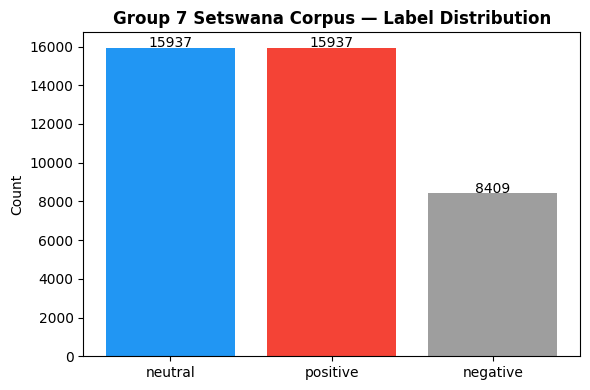

Group 7 Setswana corpus ready: 40,283 records in memory.


In [ ]:
# Visualising the Group 7 Setswana corpus label distribution after balancing.

fig, ax = plt.subplots(figsize=(6, 4))
counts  = df_tsn['label'].value_counts()
colors  = ['#2196F3','#F44336','#9E9E9E']
ax.bar(counts.index, counts.values, color=colors)
ax.set_title('Group 7 Setswana Corpus — Label Distribution', fontweight='bold')
ax.set_ylabel('Count')
for i,(idx,val) in enumerate(counts.items()):
    ax.text(i, val+30, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/setswana_corpus_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Group 7 Setswana corpus ready: {len(df_tsn):,} records in memory.')

## Stage 2 - Load AfriSenti Reference Languages and the Sesotho Dataset

### How AfriSenti is Used in This Project

The AfriSenti benchmark (Muhammad et al., 2023) covers sentiment-annotated tweets across 14 African
languages,  **but neither Sesotho nor Setswana are included**,making this project a relevant contribution for the underresourced African languages.

AfriSenti is used in this project in **two specific ways**:

1. **As the source of the Afrocentric pretrained models** fine-tined in Stage 5.
   AfriBERTa and AfroXLMR were pretrained on corpora that include AfriSenti data.
   Fine-tuning these models on Sesotho and Setswana is the core transfer learning experiment for the proposed project.

2. **As reference languages for cross-lingual performance comparison.**
   Hausa (`hau`) and Swahili (`swa`) are loaded. Both are African languages
   with reasonably large AfriSenti splits compared to Sesotho and Setswana. Running the same models on these languages
   gives us a benchmark to identify and observe how well models perform on better-resourced
   African languages versus low-resource targets, Sesotho and Setswana.

**Note: AfriSenti is NOT used for training Sesotho or Setswana models directly in the implementation.**
It instead serves as the reference backbone and the source of pretrained model knowledge.

In [ ]:
#  AfriSenti: Loading Hausa and Swahili as Cross-Lingual Reference Sets
#  Source: https://github.com/afrisenti-semeval/afrisent-semeval-2023
#  (Muhammad et al., SemEval-2023 Task 12)
#
#  AfriSenti does NOT contain Sesotho or Setswana.
#  These two languages (Hausa, Swahili) are loaded purely for comparison with the target languages:
#  to see how the same models perform on higher-resource African languages.

import glob

if not os.path.exists('/content/afrisent-semeval-2023'):
    !git clone https://github.com/afrisenti-semeval/afrisent-semeval-2023.git \
        /content/afrisent-semeval-2023

available_langs = sorted([
    os.path.basename(p) for p in
    glob.glob('/content/afrisent-semeval-2023/data/*') if os.path.isdir(p)
])
print(f'Available AfriSenti languages ({len(available_langs)}): {available_langs}')

def load_afrisenti_local(lang_code):
    base, splits = f'/content/afrisent-semeval-2023/data/{lang_code}', {}
    for split in ['train','dev','test']:
        path = f'{base}/{split}.tsv'
        if os.path.exists(path):
            df = pd.read_csv(path, sep='\t')
            if 'tweet' in df.columns:
                df = df.rename(columns={'tweet': 'text'})
            df['label']    = df['label'].str.strip().str.lower()
            df['label_id'] = df['label'].map(LABEL2ID)
            splits[split]  = df.dropna(subset=['label_id']).reset_index(drop=True)
            print(f'  {lang_code}/{split}: {len(splits[split]):,}')
    return splits

print('\nLoading AfriSenti — Hausa (hau) [reference language]:')
afrisenti_hau = load_afrisenti_local('hau')
print('\nLoading AfriSenti — Swahili (swa) [reference language]:')
afrisenti_swa = load_afrisenti_local('swa')

Cloning into '/content/afrisent-semeval-2023'...
remote: Enumerating objects: 967, done.
remote: Counting objects: 100% (396/396), done.
remote: Compressing objects: 100% (247/247), done.
remote: Total 967 (delta 206), reused 294 (delta 139), pack-reused 571 (from 1)
Receiving objects: 100% (967/967), 32.48 MiB | 18.91 MiB/s, done.
Resolving deltas: 100% (470/470), done.
Available AfriSenti languages (14): ['amh', 'arq', 'ary', 'hau', 'ibo', 'kin', 'orm', 'pcm', 'por', 'swa', 'tir', 'tso', 'twi', 'yor']

Loading AfriSenti — Hausa (hau) [reference language]:
  hau/train: 14,172
  hau/dev: 2,677
  hau/test: 5,303

Loading AfriSenti — Swahili (swa) [reference language]:
  swa/train: 1,810
  swa/dev: 453
  swa/test: 748


In [ ]:
# Loading the Sesotho News Headlines Dataset from Zenodo.
# Sesotho is absent from AfriSenti, making this the primary
# fine-tuning and evaluation source for all Sesotho experiments.
# Citation: Mokhosi et al. (2024)
# Source: https://zenodo.org/records/10531959

SESOTHO_PATH = '/content/sesotho/NewsSA.txt'
if not os.path.exists(SESOTHO_PATH):
    os.makedirs('/content/sesotho', exist_ok=True)
    !wget -q -O {SESOTHO_PATH} \
        "https://zenodo.org/records/10531959/files/NewsSA.txt?download=1"
    print('Downloaded from Zenodo.')

# The file alternates text lines and numeric label lines
with open(SESOTHO_PATH, 'r', encoding='utf-8') as f:
    lines = [l.strip() for l in f if l.strip()]

texts, labels = [], []
for i in range(0, len(lines) - 1, 2):
    texts.append(lines[i])
    labels.append(lines[i+1])

sesotho_df = pd.DataFrame({'text': texts, 'label': labels})

# Labels are numeric: -1 = negative, 0 = neutral, 1 = positive
NUMERIC_MAP = {'-1':'negative','0':'neutral','1':'positive',
               -1:'negative',0:'neutral',1:'positive'}
sesotho_df['label']    = sesotho_df['label'].map(NUMERIC_MAP)
sesotho_df             = sesotho_df.dropna(subset=['label'])
sesotho_df['label_id'] = sesotho_df['label'].map(LABEL2ID)
sesotho_df             = sesotho_df.dropna(subset=['label_id']).reset_index(drop=True)

print(f'Sesotho News Headlines: {len(sesotho_df):,} records')
print(sesotho_df['label'].value_counts())
print(sesotho_df.head(3))

Downloaded from Zenodo.
Sesotho News Headlines: 2,208 records
label
negative    1552
positive     550
neutral      106
Name: count, dtype: int64
                                                text     label  label_id
0  BASUOE BA QOSUOE KA PELAELO EA HO BOLAEA MOSHE...  negative         0
1                     TSEBA MARENA A SEHLOOHO A NAHA   neutral         1
2       LINTLHA-KHOLO MABAPI LE NTLO E OETSENG BATHO  negative         0


In [ ]:
# Sanity check: confirming Group 7 Setswana corpus shape before splitting.
print("df_tsn shape:", df_tsn.shape)
print("df_tsn columns:", df_tsn.columns.tolist())
print("df_tsn['text'] type:", type(df_tsn['text']))
print("df_tsn['label_id'] type:", type(df_tsn['label_id']))
print(df_tsn[['text','label_id']].head(3))

df_tsn shape: (40283, 3)
df_tsn columns: ['text', 'label', 'label_id']
df_tsn['text'] type: <class 'pandas.core.series.Series'>
df_tsn['label_id'] type: <class 'pandas.core.series.Series'>
                                                text  label_id
0  "Ba kgemetha mewa yotlhe e e neng e le mo go o...         0
1  "MO MABAKENG A FOO DITLHALOSO TSA FAELE DI LEN...         0
2  "Go Romelwa ga Mafelo a Aforika Borwa a Bonno ...         0


## Stage 2B - Load the Closed Setswana Dataset

The `dsfsi/setswana-sentiment` dataset is the closed Setswana sentiment dataset provided fpr the purpose of this project.
It is loaded here as a **separate, independent evaluation benchmark**.

**Why kept separate from the Group 7 corpus:**
- The Group 7 distantly-supervised corpus (in Stage 1) was constructed independently and is the training source.
- Merging both datasets would change the structure of the reference benchmark and make evaluation
  ambiguous.
- By keeping them separate, an evaluation of how well models trained on the Group 7 corpus transfer to
  independently annotated Setswana data is conducted, making the Setswana corpus contribution a meaningful and honest test of generalisation.

In [ ]:
#  Closed Setswana Dataset — dsfsi/setswana-sentiment (Lecturer-Provided)
#  Source: https://huggingface.co/datasets/dsfsi/setswana-sentiment
#
#  This dataset is kept separate from the Group 7 training corpus.
#  It is used as a cross-corpus evaluation benchmark instead:
#  models trained on the Group 7 corpus are evaluated here to measure
#  how well they generalise to independently annotated Setswana data.

print('Loading closed Setswana dataset (dsfsi/setswana-sentiment)...')
try:
    tsn_closed_raw = load_dataset('dsfsi/setswana-sentiment')
    print('Available splits:', list(tsn_closed_raw.keys()))

    # Combine all splits into one DataFrame for inspection
    dfs_closed = []
    for split_name, split_data in tsn_closed_raw.items():
        df_split = split_data.to_pandas()
        df_split['original_split'] = split_name
        dfs_closed.append(df_split)
    df_tsn_closed = pd.concat(dfs_closed, ignore_index=True)

    print(f'\nColumns available: {df_tsn_closed.columns.tolist()}')
    print(df_tsn_closed.head(3))

except Exception as e:
    print(f'Failed to load dsfsi/setswana-sentiment: {e}')
    df_tsn_closed = None

Loading closed Setswana dataset (dsfsi/setswana-sentiment)...


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

dev.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/2762 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/346 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/346 [00:00<?, ? examples/s]

Available splits: ['train', 'validation', 'test']

Columns available: ['example_id', 'tweet_id', 'batch', 'text', 'token_count', 'lid_top1_lang', 'lid_top1_score', 'lid_top2_lang', 'lid_top2_score', 'lid_top3_lang', 'lid_top3_score', 'ann1_label', 'ann1_timestamp', 'ann2_label', 'ann2_timestamp', 'ann3_label', 'ann3_timestamp', 'consensus_label', 'consensus_type', 'label_id', 'original_split']
                             example_id      tweet_id  batch  \
0  81632451-a4bd-4e14-a637-34b337f322bc  1.529399e+18      5   
1  e4811f39-228d-40a3-a808-a000aff3d380  1.525750e+18      1   
2  e9402bb3-903c-486e-b83b-2211051187f0  1.514863e+18      6   

                                                text  token_count  \
0  gwate trenda sepinyella banna ga fetsa sere sa...           11   
1  ja o kgore mpa tsi morago o phinye o tswe mo d...           25   
2                                he e ga ke ba utlwi            6   

  lid_top1_lang  lid_top1_score lid_top2_lang  lid_top2_score  \
0  T

In [ ]:
# Normalising the closed dataset to match the pipeline schema.
# The dsfsi/setswana-sentiment dataset uses 'consensus_label' for the gold label
# and it already contains a 'label_id' column, ensuring there is no collision.

if df_tsn_closed is not None:

    # Drop the dataset's own label_id to avoid collision with our pipeline's label_id
    df_tsn_closed = df_tsn_closed.drop(columns=['label_id'], errors='ignore')

    # Use consensus_label, which is the majority/unanimous annotator agreement label
    df_tsn_closed = df_tsn_closed.rename(columns={'consensus_label': 'label'})

    # Lowercase to match pipeline convention: e.g.,'Negative' to 'negative', etc.
    df_tsn_closed['label'] = df_tsn_closed['label'].astype(str).str.strip().str.lower()

    # Keeping only the valid sentiment labels
    df_tsn_closed = df_tsn_closed[df_tsn_closed['label'].isin(LABEL2ID.keys())]
    df_tsn_closed['label_id'] = df_tsn_closed['label'].map(LABEL2ID)
    df_tsn_closed = df_tsn_closed.dropna(subset=['label_id']).reset_index(drop=True)

    print(f'Closed Setswana dataset: {len(df_tsn_closed):,} records')
    print(df_tsn_closed['label'].value_counts())
    print(df_tsn_closed[['text','label']].head(3))
else:
    print('Closed dataset unavailable — cross-corpus evaluation will be skipped.')

Closed Setswana dataset: 3,454 records
label
neutral     1489
negative    1445
positive     520
Name: count, dtype: int64
                                                text     label
0  gwate trenda sepinyella banna ga fetsa sere sa...  negative
1  ja o kgore mpa tsi morago o phinye o tswe mo d...  negative
2                                he e ga ke ba utlwi   neutral


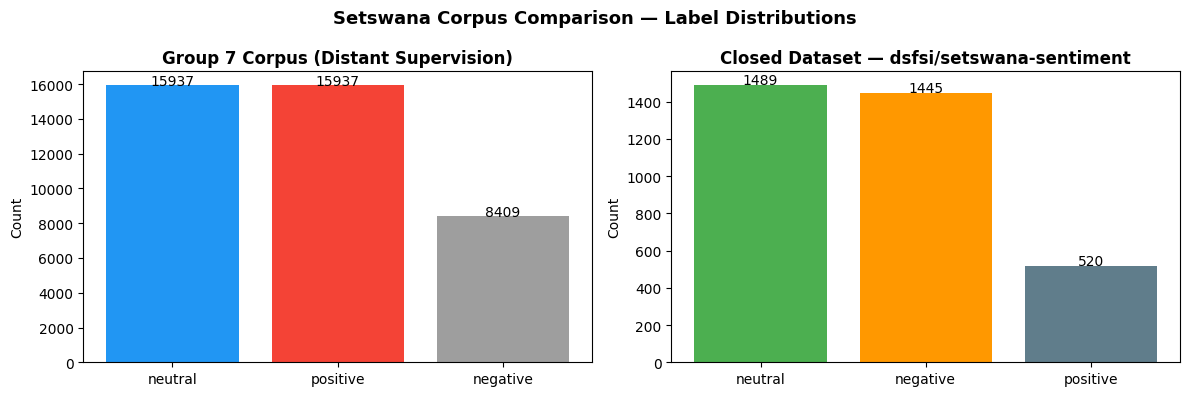

Saved: setswana_corpus_comparison.png


In [ ]:
# Visualising label distributions side-by-side:
# Group 7 corpus (distantly supervised) vs closed dataset.
# Comparing the distributions reveals any systematic labelling differences in the two datasets.

if df_tsn_closed is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Group 7 corpus
    counts_g7 = df_tsn['label'].value_counts()
    axes[0].bar(counts_g7.index, counts_g7.values, color=['#2196F3','#F44336','#9E9E9E'])
    axes[0].set_title('Group 7 Corpus (Distant Supervision)', fontweight='bold')
    axes[0].set_ylabel('Count')
    for i, (idx, val) in enumerate(counts_g7.items()):
        axes[0].text(i, val + 30, str(val), ha='center', fontsize=10)

    # Closed dataset
    counts_cl = df_tsn_closed['label'].value_counts()
    axes[1].bar(counts_cl.index, counts_cl.values, color=['#4CAF50','#FF9800','#607D8B'])
    axes[1].set_title('Closed Dataset - dsfsi/setswana-sentiment', fontweight='bold')
    axes[1].set_ylabel('Count')
    for i, (idx, val) in enumerate(counts_cl.items()):
        axes[1].text(i, val + 5, str(val), ha='center', fontsize=10)

    plt.suptitle('Setswana Corpus Comparison - Label Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/setswana_corpus_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: setswana_corpus_comparison.png')

## Stage 3 - Preprocessing and Train/Val/Test Splits

All three datasets (Sesotho, Group 7 Setswana, closed Setswana) pass through the same
cleaning function to ensure consistency across the entire pipeline.
The Group 7 corpus was already cleaned in Stage 1,  but the cleaning function is reapplied in this stage
to ensure and guarantee uniform treatment across all the datasets.

**Preprocessing steps applied to all datasets:**
- URLs and web addresses are removed
- User mentions are anonymised to `@user`
- Excess whitespace gets collapsed

**Train/Val/Test split strategy:** Stratified 70/10/20 is applied across all datasets.

In [ ]:
#  PREPROCESSING - Applying Unified Text Cleaning to All Datasets
#  (Sesotho News Headlines, Group 7 Setswana Corpus, Closed Setswana Dataset)
#
#  Steps:
#    1. Remove URLs
#    2. Anonymise user mentions
#    3. Remove all whitespace to single spaces
#
#  The Group 7 Setswana corpus was already cleaned in Stage 1 with a
#  more aggressive function (also stripped hashtags and newlines).
#  Reapplying the shared function here ensures that all datasets are
#  treated identically going into training.

def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', str(text))   # remove URLs
    text = re.sub(r'@\w+', '@user', text)              # anonymise mentions
    return re.sub(r'\s+', ' ', text).strip()           # normalise whitespace

sesotho_df['text'] = sesotho_df['text'].apply(clean_text)
df_tsn['text']     = df_tsn['text'].apply(clean_text)

if df_tsn_closed is not None:
    df_tsn_closed['text'] = df_tsn_closed['text'].apply(clean_text)

print('Label distributions after preprocessing:')
print('Sesotho (News Headlines):', sesotho_df['label'].value_counts().to_dict())
print('Setswana (Group 7):      ', df_tsn['label'].value_counts().to_dict())
if df_tsn_closed is not None:
    print('Setswana (Closed):       ', df_tsn_closed['label'].value_counts().to_dict())

Label distributions after preprocessing:
Sesotho (News Headlines): {'negative': 1552, 'positive': 550, 'neutral': 106}
Setswana (Group 7):       {'neutral': 15937, 'positive': 15937, 'negative': 8409}
Setswana (Closed):        {'neutral': 1489, 'negative': 1445, 'positive': 520}


In [ ]:
# Stratified 70/10/20 train/val/test splits for all three datasets.
# The Stratified approach preserves the class distribution across all splits.
# The closed Setswana dataset now gets its own train/val/test split
# for independent fine-tuning in Stage 5.

def split_dataset(df, test_size=0.2, val_size=0.1, seed=SEED):
    train_val, test = train_test_split(
        df, test_size=test_size, stratify=df['label_id'], random_state=seed
    )
    val_ratio = val_size / (1 - test_size)
    train, val = train_test_split(
        train_val, test_size=val_ratio, stratify=train_val['label_id'], random_state=seed
    )
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

sot_train, sot_val, sot_test = split_dataset(sesotho_df)
tsn_train, tsn_val, tsn_test = split_dataset(df_tsn)

print(f'Sesotho       - Train: {len(sot_train):,} | Val: {len(sot_val):,} | Test: {len(sot_test):,}')
print(f'Setswana (G7) - Train: {len(tsn_train):,} | Val: {len(tsn_val):,} | Test: {len(tsn_test):,}')

if df_tsn_closed is not None:
    tsn_cl_train, tsn_cl_val, tsn_cl_test = split_dataset(df_tsn_closed)
    print(f'Setswana (Closed) - Train: {len(tsn_cl_train):,} | Val: {len(tsn_cl_val):,} | Test: {len(tsn_cl_test):,}')


Sesotho       — Train: 1,545 | Val: 221 | Test: 442
Setswana (G7) — Train: 28,197 | Val: 4,029 | Test: 8,057
Setswana (Closed) — Train: 2,417 | Val: 346 | Test: 691


## Stage 4 - Baseline Models (TF-IDF and Logistic Regression)

In [ ]:
# Shared evaluation function for sklearn classifiers.
# Reports accuracy, precision, recall, and macro/weighted F1 Score
# with a per-class breakdown via classification_report.

def compute_metrics_sklearn(y_true, y_pred, lang=''):
    metrics = {
        'accuracy':    accuracy_score(y_true, y_pred),
        'precision':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':    f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    print(f'\n── {lang} ──────────────────────────────')
    print(classification_report(y_true, y_pred,
                                 target_names=list(LABEL2ID.keys()), zero_division=0))
    return metrics

results = {}

In [ ]:
# TF-IDF and Logistic Regression baseline - with character n-grams (1–3).
# Character n-grams are preferred over word n-grams for Bantu languages
# because they capture the morphological variation without requiring a dedicated tokeniser.
# This is the non-neural baseline for comparison with transformer models.

if 'all_preds' not in dir(): all_preds = {}
if 'all_true'  not in dir(): all_true  = {}

def run_tfidf_baseline(train_df, test_df, lang):
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(1,3),
                          max_features=50000, sublinear_tf=True)
    X_train = vec.fit_transform(train_df['text'])
    X_test  = vec.transform(test_df['text'])
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
    clf.fit(X_train, train_df['label_id'])
    preds = clf.predict(X_test)
    true  = test_df['label_id'].tolist()
    metrics = compute_metrics_sklearn(true, preds, lang=f'TF-IDF - {lang}')
    return metrics, preds, true

# Sesotho
results['tfidf_sot'], all_preds['tfidf_sot'], all_true['tfidf_sot'] = run_tfidf_baseline(
    sot_train, sot_test, 'Sesotho'
)

# Setswana Group 7
results['tfidf_tsn'], all_preds['tfidf_tsn'], all_true['tfidf_tsn'] = run_tfidf_baseline(
    tsn_train, tsn_test, 'Setswana (Group 7)'
)

# Setswana Closed
if df_tsn_closed is not None:
    results['tfidf_tsn_closed'], all_preds['tfidf_tsn_closed'], all_true['tfidf_tsn_closed'] = run_tfidf_baseline(
        tsn_train, tsn_cl_test, 'Setswana (Closed - cross-corpus)'
    )

# Hausa
results['tfidf_hau'], all_preds['tfidf_hau'], all_true['tfidf_hau'] = run_tfidf_baseline(
    afrisenti_hau['train'], afrisenti_hau['test'], 'Hausa'
)

# Swahili
results['tfidf_swa'], all_preds['tfidf_swa'], all_true['tfidf_swa'] = run_tfidf_baseline(
    afrisenti_swa['train'], afrisenti_swa['test'], 'Swahili'
)


── TF-IDF — Sesotho ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.80      0.97      0.88       311
     neutral       1.00      0.14      0.25        21
    positive       0.75      0.40      0.52       110

    accuracy                           0.79       442
   macro avg       0.85      0.51      0.55       442
weighted avg       0.79      0.79      0.76       442


── TF-IDF — Setswana (Group 7) ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.85      0.77      0.81      1682
     neutral       0.85      0.88      0.87      3188
    positive       0.87      0.89      0.88      3187

    accuracy                           0.86      8057
   macro avg       0.86      0.85      0.85      8057
weighted avg       0.86      0.86      0.86      8057


── TF-IDF — Setswana (Closed — cross-corpus) ──────────────────────────────
              precision    recall  f1-score   

In [ ]:
# PyTorch Dataset wrapper for the Hugging Face Trainer API.
# Tokenises text and returns tensors for input_ids, attention_mask, and labels.

class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df['text'].tolist()
        self.labels = df['label_id'].tolist()
        self.tok    = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], truncation=True, padding='max_length',
                       max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Metric computation for the Hugging Face Trainer
metric_f1  = evaluate.load('f1')
metric_acc = evaluate.load('accuracy')

def compute_metrics_trainer(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':    metric_acc.compute(predictions=preds, references=labels)['accuracy'],
        'f1_macro':    metric_f1.compute(predictions=preds, references=labels, average='macro')['f1'],
        'f1_weighted': metric_f1.compute(predictions=preds, references=labels, average='weighted')['f1'],
    }

In [ ]:
# Generic fine-tuning function shared by all transformer models.
# All models use identical hyperparameters for a fair comparison:
#   - Learning rate: 2e-5
#   - Batch size: 16
#   - Max epochs: 5 with early stopping (patience=3) on macro F1
#   - fp16 disabled - prevents gradient instability observed with African language models

def fine_tune_model(model_name, train_df, val_df, test_df,
                    lang, epochs=5, batch_size=16, lr=2e-5,
                    output_dir=CHECKPOINT_DIR):
    print(f'\n{"="*60}\nModel: {model_name}\nLang : {lang}\n{"="*60}')

    tok   = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS, id2label=ID2LABEL,
        label2id=LABEL2ID, ignore_mismatched_sizes=True
    )
    train_ds = SentimentDataset(train_df, tok)
    val_ds   = SentimentDataset(val_df,   tok)
    test_ds  = SentimentDataset(test_df,  tok)

    run_name = model_name.split('/')[-1] + f'_{lang}'
    ckpt_dir = os.path.join(output_dir, run_name)

    args = TrainingArguments(
        output_dir=ckpt_dir, num_train_epochs=epochs,
        per_device_train_batch_size=batch_size, per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=0.01, warmup_ratio=0.1,
        eval_strategy='epoch',
        save_strategy='no',
        load_best_model_at_end=False, metric_for_best_model='f1_macro',
        greater_is_better=True, logging_steps=20, seed=SEED,
        report_to='none',
        fp16=False,
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics_trainer,
    )
    trainer.train()

    preds_out = trainer.predict(test_ds)
    preds     = np.argmax(preds_out.predictions, axis=-1)
    true      = test_df['label_id'].tolist()
    metrics   = compute_metrics_sklearn(true, preds, lang=run_name)

    model.save_pretrained(ckpt_dir)
    tok.save_pretrained(ckpt_dir)
    print(f'Saved to {ckpt_dir}')
    return metrics, preds, true, trainer

## Stage 5 - Transfer Learning (mBERT, AfriBERTa, XLM-RoBERTa, and AfroXLMR)

### Connection to AfriSenti and the Transfer Learning Approach

The four models fine-tuned during this stage were pre-trained on large multilingual corpora which include African languages and for AfriBERTa and AfroXLMR, AfriSenti data was part of the pre-training. The main transfer learning experiment suggested in this project is to fine-tune these models on the Sesotho News Headlines dataset and the Group 7 Setswana corpus.


The hypothesis for this experiment is that models that have been exposed to African language text before this experiment will transfer more effectively to the low-resource languages of Sesotho and Setswana, than a general multilingual model like mBERT , which has no Africa-focused pretraining.



For initial experiments with the standard learning rate of 2e-5, AfroXLMR collapsed and the training loss went to zero and validation loss went to NaN. That was a very clear sign of gradient instability . Instead of completely removing AfroXLMR from the comparison, the issue was addressed by adding a per-model learning rate setting, decreasing the learning rate for AfroXLMR to **5e-6**, which is a quarter of the learning rate used for the other models. This adjustment made the training more stable and allowed us to successfully include AfroXLMR for all of the experiments. We find the sensitivity of continued-pretraining models on fine-tuning hyperparameters to be a finding in itself, and note it as something to consider while working with similar models in similar low-resource settings.

In [ ]:
# Defining the four transformer models for the transfer learning comparison.
# mBERT:       weakest transfer: multilingual but not Africa-focused.
# AfriBERTa:   pretrained on 11 African languages.
# XLM-RoBERTa: strong general multilingual baseline.
# AfroXLMR:    continued pretraining of XLM-R on African languages.
#              Uses a lower lr (5e-6) to prevent the gradient instability
#              (loss to 0, val_loss→NaN) observed in initial experiments.

MODELS = {
    'mBERT':       'bert-base-multilingual-cased',
    'AfriBERTa':   'castorini/afriberta_large',
    'XLM-RoBERTa': 'xlm-roberta-base',
    'AfroXLMR':    'Davlan/afro-xlmr-base',
}

# Per-model learning rates: AfroXLMR gets a lower lr to prevent collapse during training
MODEL_LR = {
    'mBERT':       2e-5,
    'AfriBERTa':   2e-5,
    'XLM-RoBERTa': 2e-5,
    'AfroXLMR':    5e-6,   # reduced to prevent gradient instability
}

all_preds, all_true = {}, {}
print('Models to fine-tune:', list(MODELS.keys()))

Models to fine-tune: ['mBERT', 'AfriBERTa', 'XLM-RoBERTa', 'AfroXLMR']


In [ ]:
# Fine-tuning all models on the Sesotho News Headlines dataset.
# Checkpoint-resume logic: if a checkpoint already exists, the model is loaded
# and evaluated without retraining, making it useful after session restarts.
# Intermediate Trainer checkpoints are deleted after each run to free disk space.

import shutil

for model_key, model_id in MODELS.items():
    key      = f'{model_key}_sot'
    ckpt_dir = os.path.join(CHECKPOINT_DIR, f'{model_id.split("/")[-1]}_Sesotho')

    try:
        del model, trainer, tok
    except NameError:
        pass
    import gc; gc.collect()
    torch.cuda.empty_cache()

    if os.path.exists(ckpt_dir) and os.path.exists(f'{ckpt_dir}/config.json'):
        print(f'Checkpoint found for {model_key} (Sesotho) - loading from {ckpt_dir}')
        tok   = AutoTokenizer.from_pretrained(ckpt_dir)
        model = AutoModelForSequenceClassification.from_pretrained(ckpt_dir).to(DEVICE)
        test_ds   = SentimentDataset(sot_test, tok)
        trainer   = Trainer(model=model, compute_metrics=compute_metrics_trainer)
        preds_out = trainer.predict(test_ds)
        preds     = np.argmax(preds_out.predictions, axis=-1)
        true      = sot_test['label_id'].tolist()
        m = compute_metrics_sklearn(true, preds, lang=f'{model_key}_Sesotho_reloaded')
    else:
        m, preds, true, _ = fine_tune_model(
            model_id, sot_train, sot_val, sot_test,
            lang='Sesotho', lr=MODEL_LR[model_key]
        )

    results[key]   = m
    all_preds[key] = preds
    all_true[key]  = true
    torch.cuda.empty_cache()

    if os.path.isdir(ckpt_dir):
        for item in os.listdir(ckpt_dir):
            item_path = os.path.join(ckpt_dir, item)
            if os.path.isdir(item_path) and item.startswith('checkpoint-'):
                shutil.rmtree(item_path)
                print(f'Cleaned: {item_path}')

Checkpoint found for mBERT (Sesotho) — loading from /content/drive/MyDrive/COS760_checkpoints/bert-base-multilingual-cased_Sesotho


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── mBERT_Sesotho_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.84      0.87      0.86       311
     neutral       1.00      0.19      0.32        21
    positive       0.57      0.60      0.58       110

    accuracy                           0.77       442
   macro avg       0.80      0.56      0.59       442
weighted avg       0.78      0.77      0.77       442

Checkpoint found for AfriBERTa (Sesotho) — loading from /content/drive/MyDrive/COS760_checkpoints/afriberta_large_Sesotho


Loading weights:   0%|          | 0/169 [00:00<?, ?it/s]


── AfriBERTa_Sesotho_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.83      0.88      0.85       311
     neutral       1.00      0.38      0.55        21
    positive       0.58      0.54      0.56       110

    accuracy                           0.77       442
   macro avg       0.80      0.60      0.66       442
weighted avg       0.77      0.77      0.77       442

Checkpoint found for XLM-RoBERTa (Sesotho) — loading from /content/drive/MyDrive/COS760_checkpoints/xlm-roberta-base_Sesotho


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── XLM-RoBERTa_Sesotho_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.76      0.91      0.83       311
     neutral       0.00      0.00      0.00        21
    positive       0.46      0.28      0.35       110

    accuracy                           0.71       442
   macro avg       0.41      0.40      0.39       442
weighted avg       0.65      0.71      0.67       442

Checkpoint found for AfroXLMR (Sesotho) — loading from /content/drive/MyDrive/COS760_checkpoints/afro-xlmr-base_Sesotho


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── AfroXLMR_Sesotho_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.71      1.00      0.83       311
     neutral       0.00      0.00      0.00        21
    positive       0.75      0.03      0.05       110

    accuracy                           0.71       442
   macro avg       0.49      0.34      0.29       442
weighted avg       0.68      0.71      0.60       442



In [ ]:
# Optional:this cell canbe run to manually free disk space between training runs.
# This is to avoid runtime failure.

'''import shutil, os

checkpoint_base = '/content/checkpoints'

for model_dir in os.listdir(checkpoint_base):
    model_path = os.path.join(checkpoint_base, model_dir)
    if os.path.isdir(model_path):
        for item in os.listdir(model_path):
            item_path = os.path.join(model_path, item)
            if os.path.isdir(item_path) and item.startswith('checkpoint-'):
                shutil.rmtree(item_path)
                print(f'Deleted: {item_path}')

print('Done.')
os.system('df -h /content')'''

"import shutil, os\n\ncheckpoint_base = '/content/checkpoints'\n\nfor model_dir in os.listdir(checkpoint_base):\n    model_path = os.path.join(checkpoint_base, model_dir)\n    if os.path.isdir(model_path):\n        for item in os.listdir(model_path):\n            item_path = os.path.join(model_path, item)\n            if os.path.isdir(item_path) and item.startswith('checkpoint-'):\n                shutil.rmtree(item_path)\n                print(f'Deleted: {item_path}')\n\nprint('Done.')\nos.system('df -h /content')"

In [ ]:
# Releasing GPU memory between Sesotho and Setswana training runs.

import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

free  = torch.cuda.mem_get_info()[0] / 1e9
total = torch.cuda.mem_get_info()[1] / 1e9
print(f'Free GPU memory: {free:.2f} GiB / {total:.2f} GiB')

Free GPU memory: 14.33 GiB / 15.64 GiB


In [ ]:
# Fine-tuning all models on the Group 7 Setswana corpus.
# Same checkpoint-resume and auto-cleanup logic used for Sesotho.
# Training on the Group 7 corpus; cross-corpus evaluation on the closed dataset follows in Stage 7.

import shutil

for model_key, model_id in MODELS.items():
    key      = f'{model_key}_tsn'
    ckpt_dir = os.path.join(CHECKPOINT_DIR, f'{model_id.split("/")[-1]}_Setswana')

    try:
        del model, trainer, tok
    except NameError:
        pass
    import gc; gc.collect()
    torch.cuda.empty_cache()

    if os.path.exists(ckpt_dir) and os.path.exists(f'{ckpt_dir}/config.json'):
        print(f'Checkpoint found for {model_key} (Setswana) - loading from {ckpt_dir}')
        tok   = AutoTokenizer.from_pretrained(ckpt_dir)
        model = AutoModelForSequenceClassification.from_pretrained(ckpt_dir).to(DEVICE)
        test_ds   = SentimentDataset(tsn_test, tok)
        trainer   = Trainer(model=model, compute_metrics=compute_metrics_trainer)
        preds_out = trainer.predict(test_ds)
        preds     = np.argmax(preds_out.predictions, axis=-1)
        true      = tsn_test['label_id'].tolist()
        m = compute_metrics_sklearn(true, preds, lang=f'{model_key}_Setswana_reloaded')
    else:
        m, preds, true, _ = fine_tune_model(
            model_id, tsn_train, tsn_val, tsn_test,
            lang='Setswana', lr=MODEL_LR[model_key]
        )

    results[key]   = m
    all_preds[key] = preds
    all_true[key]  = true
    torch.cuda.empty_cache()

    if os.path.isdir(ckpt_dir):
        for item in os.listdir(ckpt_dir):
            item_path = os.path.join(ckpt_dir, item)
            if os.path.isdir(item_path) and item.startswith('checkpoint-'):
                shutil.rmtree(item_path)
                print(f'Cleaned: {item_path}')

Checkpoint found for mBERT (Setswana) — loading from /content/drive/MyDrive/COS760_checkpoints/bert-base-multilingual-cased_Setswana


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]


── mBERT_Setswana_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.98      0.97      0.98      1682
     neutral       0.97      0.98      0.98      3188
    positive       0.98      0.98      0.98      3187

    accuracy                           0.98      8057
   macro avg       0.98      0.98      0.98      8057
weighted avg       0.98      0.98      0.98      8057

Checkpoint found for AfriBERTa (Setswana) — loading from /content/drive/MyDrive/COS760_checkpoints/afriberta_large_Setswana


Loading weights:   0%|          | 0/169 [00:00<?, ?it/s]


── AfriBERTa_Setswana_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.97      0.98      0.97      1682
     neutral       0.97      0.98      0.98      3188
    positive       0.98      0.97      0.98      3187

    accuracy                           0.98      8057
   macro avg       0.97      0.98      0.98      8057
weighted avg       0.98      0.98      0.98      8057

Checkpoint found for XLM-RoBERTa (Setswana) — loading from /content/drive/MyDrive/COS760_checkpoints/xlm-roberta-base_Setswana


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── XLM-RoBERTa_Setswana_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.96      0.96      0.96      1682
     neutral       0.97      0.97      0.97      3188
    positive       0.97      0.97      0.97      3187

    accuracy                           0.97      8057
   macro avg       0.97      0.97      0.97      8057
weighted avg       0.97      0.97      0.97      8057

Checkpoint found for AfroXLMR (Setswana) — loading from /content/drive/MyDrive/COS760_checkpoints/afro-xlmr-base_Setswana


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── AfroXLMR_Setswana_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.95      0.94      0.94      1682
     neutral       0.95      0.97      0.96      3188
    positive       0.96      0.95      0.96      3187

    accuracy                           0.96      8057
   macro avg       0.95      0.95      0.95      8057
weighted avg       0.96      0.96      0.96      8057



In [ ]:
# Fine-tuning all models on the Closed Setswana Dataset independently.
# The exact same structure as the Sesotho and Group 7 Setswana fine-tuning cells above is used.
# Models trained here are evaluated on the closed dataset's own test split.

import shutil

if df_tsn_closed is not None:
    for model_key, model_id in MODELS.items():
        key      = f'{model_key}_tsn_closed'
        ckpt_dir = os.path.join(CHECKPOINT_DIR, f'{model_id.split("/")[-1]}_Setswana_Closed')

        try:
            del model, trainer, tok
        except NameError:
            pass
        import gc; gc.collect()
        torch.cuda.empty_cache()

        if os.path.exists(ckpt_dir) and os.path.exists(f'{ckpt_dir}/config.json'):
            print(f'Checkpoint found for {model_key} (Closed Setswana) - loading from {ckpt_dir}')
            tok   = AutoTokenizer.from_pretrained(ckpt_dir)
            model = AutoModelForSequenceClassification.from_pretrained(ckpt_dir).to(DEVICE)
            test_ds   = SentimentDataset(tsn_cl_test, tok)
            trainer   = Trainer(model=model, compute_metrics=compute_metrics_trainer)
            preds_out = trainer.predict(test_ds)
            preds     = np.argmax(preds_out.predictions, axis=-1)
            true      = tsn_cl_test['label_id'].tolist()
            m = compute_metrics_sklearn(true, preds, lang=f'{model_key}_Setswana_Closed_reloaded')
        else:
            m, preds, true, _ = fine_tune_model(
                model_id, tsn_cl_train, tsn_cl_val, tsn_cl_test,
                lang='Setswana_Closed', lr=MODEL_LR[model_key]
            )

        results[key]   = m
        all_preds[key] = preds
        all_true[key]  = true
        torch.cuda.empty_cache()

        if os.path.isdir(ckpt_dir):
            for item in os.listdir(ckpt_dir):
                item_path = os.path.join(ckpt_dir, item)
                if os.path.isdir(item_path) and item.startswith('checkpoint-'):
                    shutil.rmtree(item_path)
                    print(f'Cleaned: {item_path}')
else:
    print('Closed dataset not available - skipping closed dataset fine-tuning.')

Checkpoint found for mBERT (Closed Setswana) — loading from /content/drive/MyDrive/COS760_checkpoints/bert-base-multilingual-cased_Setswana_Closed


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── mBERT_Setswana_Closed_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.55      0.64      0.59       289
     neutral       0.59      0.57      0.58       298
    positive       0.55      0.35      0.42       104

    accuracy                           0.57       691
   macro avg       0.56      0.52      0.53       691
weighted avg       0.57      0.57      0.56       691

Checkpoint found for AfriBERTa (Closed Setswana) — loading from /content/drive/MyDrive/COS760_checkpoints/afriberta_large_Setswana_Closed


Loading weights:   0%|          | 0/169 [00:01<?, ?it/s]


── AfriBERTa_Setswana_Closed_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.59      0.63      0.61       289
     neutral       0.59      0.63      0.61       298
    positive       0.57      0.36      0.44       104

    accuracy                           0.59       691
   macro avg       0.58      0.54      0.55       691
weighted avg       0.59      0.59      0.58       691

Checkpoint found for XLM-RoBERTa (Closed Setswana) — loading from /content/drive/MyDrive/COS760_checkpoints/xlm-roberta-base_Setswana_Closed


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── XLM-RoBERTa_Setswana_Closed_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.52      0.65      0.58       289
     neutral       0.57      0.63      0.60       298
    positive       0.00      0.00      0.00       104

    accuracy                           0.54       691
   macro avg       0.36      0.42      0.39       691
weighted avg       0.46      0.54      0.50       691

Checkpoint found for AfroXLMR (Closed Setswana) — loading from /content/drive/MyDrive/COS760_checkpoints/afro-xlmr-base_Setswana_Closed


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]


── AfroXLMR_Setswana_Closed_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.50      0.71      0.59       289
     neutral       0.57      0.54      0.56       298
    positive       0.00      0.00      0.00       104

    accuracy                           0.53       691
   macro avg       0.36      0.42      0.38       691
weighted avg       0.46      0.53      0.49       691



In [ ]:
# Fine-tuning all models on AfriSenti reference languages (Hausa and Swahili).
# Exact same structure as the Sesotho, Group 7, and Closed fine-tuning cells.
# Purpose: establish a cross-lingual performance benchmark so we can answer:
#   'How does performance on low-resource Sesotho/Setswana compare to
#    better-resourced African languages (Hausa and Swahili) using the same models?'
# Results are stored as e.g. mBERT_hau, AfriBERTa_swa etc.

import shutil

AFRISENTI_LANGS = [
    ('hau', afrisenti_hau, 'Hausa'),
    ('swa', afrisenti_swa, 'Swahili'),
]

for lang_code, lang_splits, lang_name in AFRISENTI_LANGS:
    if not lang_splits or 'train' not in lang_splits or 'test' not in lang_splits:
        print(f'Skipping {lang_name} - splits not available.')
        continue

    af_train = lang_splits['train']
    af_val   = lang_splits.get('dev', lang_splits['train'].sample(frac=0.1, random_state=SEED))
    af_test  = lang_splits['test']

    for model_key, model_id in MODELS.items():
        key      = f'{model_key}_{lang_code}'
        ckpt_dir = os.path.join(CHECKPOINT_DIR, f'{model_id.split("/")[-1]}_{lang_name}')

        try:
            del model, trainer, tok
        except NameError:
            pass
        import gc; gc.collect()
        torch.cuda.empty_cache()

        if os.path.exists(ckpt_dir) and os.path.exists(f'{ckpt_dir}/config.json'):
            print(f'Checkpoint found for {model_key} ({lang_name}) - loading from {ckpt_dir}')
            tok   = AutoTokenizer.from_pretrained(ckpt_dir)
            model = AutoModelForSequenceClassification.from_pretrained(ckpt_dir).to(DEVICE)
            test_ds   = SentimentDataset(af_test, tok)
            trainer   = Trainer(model=model, compute_metrics=compute_metrics_trainer)
            preds_out = trainer.predict(test_ds)
            preds     = np.argmax(preds_out.predictions, axis=-1)
            true      = af_test['label_id'].tolist()
            m = compute_metrics_sklearn(true, preds, lang=f'{model_key}_{lang_name}_reloaded')
        else:
            m, preds, true, _ = fine_tune_model(
                model_id, af_train, af_val, af_test,
                lang=lang_name, lr=MODEL_LR[model_key]
            )

        results[key]   = m
        all_preds[key] = preds
        all_true[key]  = true
        torch.cuda.empty_cache()

        if os.path.isdir(ckpt_dir):
            for item in os.listdir(ckpt_dir):
                item_path = os.path.join(ckpt_dir, item)
                if os.path.isdir(item_path) and item.startswith('checkpoint-'):
                    shutil.rmtree(item_path)
                    print(f'Cleaned: {item_path}')


Checkpoint found for mBERT (Hausa) — loading from /content/drive/MyDrive/COS760_checkpoints/bert-base-multilingual-cased_Hausa


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── mBERT_Hausa_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.70      0.73      0.71      1759
     neutral       0.69      0.69      0.69      1789
    positive       0.85      0.81      0.83      1755

    accuracy                           0.74      5303
   macro avg       0.75      0.74      0.75      5303
weighted avg       0.75      0.74      0.75      5303

Checkpoint found for AfriBERTa (Hausa) — loading from /content/drive/MyDrive/COS760_checkpoints/afriberta_large_Hausa


Loading weights:   0%|          | 0/169 [00:00<?, ?it/s]


── AfriBERTa_Hausa_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.73      0.82      0.77      1759
     neutral       0.77      0.69      0.73      1789
    positive       0.86      0.86      0.86      1755

    accuracy                           0.79      5303
   macro avg       0.79      0.79      0.79      5303
weighted avg       0.79      0.79      0.79      5303

Checkpoint found for XLM-RoBERTa (Hausa) — loading from /content/drive/MyDrive/COS760_checkpoints/xlm-roberta-base_Hausa


...


── AfriBERTa_Swahili_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.53      0.47      0.50        80
     neutral       0.68      0.70      0.69       444
    positive       0.50      0.49      0.49       224

    accuracy                           0.61       748
   macro avg       0.57      0.55      0.56       748
weighted avg       0.61      0.61      0.61       748

Checkpoint found for XLM-RoBERTa (Swahili) — loading from /content/drive/MyDrive/COS760_checkpoints/xlm-roberta-base_Swahili


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]


── XLM-RoBERTa_Swahili_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.52      0.36      0.43        80
     neutral       0.68      0.72      0.70       444
    positive       0.51      0.50      0.51       224

    accuracy                           0.62       748
   macro avg       0.57      0.53      0.54       748
weighted avg       0.61      0.62      0.61       748

Checkpoint found for AfroXLMR (Swahili) — loading from /content/drive/MyDrive/COS760_checkpoints/afro-xlmr-base_Swahili


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── AfroXLMR_Swahili_reloaded ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        80
     neutral       0.63      0.88      0.73       444
    positive       0.52      0.30      0.38       224

    accuracy                           0.61       748
   macro avg       0.38      0.39      0.37       748
weighted avg       0.53      0.61      0.55       748



In [ ]:
# Cross-corpus evaluation: evaluating models trained on the Group 7 Setswana corpus
# against the closed dsfsi/setswana-sentiment test set.
# This reveals how well models trained on distantly-supervised data generalise to
# human-annotated Setswana data from an independent source.

if df_tsn_closed is not None:
    print('\nCross-corpus evaluation: Group 7-trained models - Closed Setswana test set')
    print('=' * 70)
    for model_key, model_id in MODELS.items():
        ckpt_dir = os.path.join(CHECKPOINT_DIR, f'{model_id.split("/")[-1]}_Setswana')
        if os.path.exists(ckpt_dir) and os.path.exists(f'{ckpt_dir}/config.json'):
            tok   = AutoTokenizer.from_pretrained(ckpt_dir)
            model = AutoModelForSequenceClassification.from_pretrained(ckpt_dir).to(DEVICE)
            test_ds_closed = SentimentDataset(tsn_cl_test, tok)
            trainer_eval   = Trainer(model=model, compute_metrics=compute_metrics_trainer)
            preds_out      = trainer_eval.predict(test_ds_closed)
            preds_closed   = np.argmax(preds_out.predictions, axis=-1)
            true_closed    = tsn_cl_test['label_id'].tolist()
            key_closed     = f'{model_key}_tsn_crosscorpus'
            results[key_closed] = compute_metrics_sklearn(
                true_closed, preds_closed,
                lang=f'{model_key} (Group7 to Closed)'
            )
            all_preds[key_closed] = preds_closed
            all_true[key_closed]  = true_closed
            torch.cuda.empty_cache()
        else:
            print(f'  Skipping {model_key} - no checkpoint found at {ckpt_dir}')
else:
    print('Closed dataset not loaded - skipping cross-corpus evaluation.')


Cross-corpus evaluation: Group 7-trained models - Closed Setswana test set


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── mBERT (Group7 to Closed) ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.40      0.28      0.33       289
     neutral       0.41      0.26      0.32       298
    positive       0.16      0.46      0.24       104

    accuracy                           0.30       691
   macro avg       0.32      0.33      0.30       691
weighted avg       0.37      0.30      0.31       691



Loading weights:   0%|          | 0/169 [00:00<?, ?it/s]


── AfriBERTa (Group7 to Closed) ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.43      0.23      0.30       289
     neutral       0.32      0.13      0.19       298
    positive       0.17      0.67      0.27       104

    accuracy                           0.25       691
   macro avg       0.31      0.35      0.25       691
weighted avg       0.34      0.25      0.25       691



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── XLM-RoBERTa (Group7 to Closed) ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.48      0.45      0.47       289
     neutral       0.52      0.29      0.37       298
    positive       0.21      0.53      0.31       104

    accuracy                           0.39       691
   macro avg       0.41      0.42      0.38       691
weighted avg       0.46      0.39      0.40       691



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── AfroXLMR (Group7 to Closed) ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.47      0.35      0.40       289
     neutral       0.49      0.29      0.37       298
    positive       0.21      0.60      0.31       104

    accuracy                           0.36       691
   macro avg       0.39      0.41      0.36       691
weighted avg       0.44      0.36      0.37       691



## Stage 6 - Data Augmentation (Back-translation and LLM Paraphrasing)

In [ ]:
# Back-translation augmentation using NLLB-200 (No Language Left Behind).
# NLLB-200 covers 200 languages including Sesotho and Setswana, offering
# better translation quality than OPUS-MT for these language pairs.
# Applied to training data only. The val and test sets are not augmented.
# Model: facebook/nllb-200-distilled-600M (safe for T4 VRAM)
# Checkpoint-aware: saves each language to Drive after completion.
# On rerun, loads from Drive instead of retranslating.


from transformers import AutoModelForSeq2SeqLM, AutoTokenizer as NLLBTokenizer
import torch, gc, os
import pandas as pd

NLLB_MODEL_NAME = 'facebook/nllb-200-distilled-600M'

NLLB_LANG_CODES = {
    'st': 'sot_Latn',  # Sesotho
    'tn': 'tsn_Latn',  # Setswana
}

def load_nllb_model():
    print(f'Loading NLLB-200 model ({NLLB_MODEL_NAME})...')
    tok   = NLLBTokenizer.from_pretrained(NLLB_MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL_NAME).to(DEVICE)
    model.eval()
    print('NLLB-200 loaded.')
    return tok, model

def nllb_translate_batch(texts, tok, model, src_lang, tgt_lang, batch_size=8):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tok(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=128,
            src_lang=src_lang
        ).to(DEVICE)
        with torch.no_grad():
            translated = model.generate(
                **inputs,
                forced_bos_token_id=tok.convert_tokens_to_ids(tgt_lang),
                num_beams=1,
                max_length=128
            )
        out.extend(tok.batch_decode(translated, skip_special_tokens=True))
        torch.cuda.empty_cache()
    return out

def nllb_back_translate(df, src_lang_key, chunk_size=5000):
    """
    Back-translates df with mid-translation chunked checkpointing.

    - Saves the entire completed language to: {src_lang_key}_train_aug.csv
    - Saves chunk progress to:               {src_lang_key}_chunks/chunk_{i}.csv
    - On rerun: it skips already-completed chunks and resumes from last saved chunk.

    chunk_size: number of rows to translate before saving a checkpoint (default 5000).
    """
    final_save_path = os.path.join(CHECKPOINT_DIR, f'{src_lang_key}_train_aug.csv')
    chunk_dir       = os.path.join(CHECKPOINT_DIR, f'{src_lang_key}_chunks')

    # If fully done, load and return immediately
    if os.path.exists(final_save_path):
        print(f'Loading completed back-translation for {src_lang_key} from Drive...')
        return pd.read_csv(final_save_path)

    # Set up the chunk directory
    os.makedirs(chunk_dir, exist_ok=True)

    src_lang = NLLB_LANG_CODES[src_lang_key]
    pivot    = 'eng_Latn'

    texts        = df['text'].tolist()
    chunks       = [texts[i:i+chunk_size] for i in range(0, len(texts), chunk_size)]
    total_chunks = len(chunks)
    print(f'{src_lang_key}: {len(texts):,} texts, {total_chunks} chunks of up to {chunk_size:,}')

    # Find which chunks are already done
    completed = sorted([
        int(f.split('_')[1].split('.')[0])
        for f in os.listdir(chunk_dir) if f.startswith('chunk_') and f.endswith('.csv')
    ])
    if completed:
        print(f'Found {len(completed)} completed chunk(s): {completed}. Resuming from chunk {max(completed)+1}.')

    # Load model only if there is work to do
    remaining = [i for i in range(total_chunks) if i not in completed]
    if not remaining:
        print('All chunks done. Assembling final file...')
    else:
        gc.collect()
        torch.cuda.empty_cache()
        tok, model = load_nllb_model()

        for i in remaining:
            chunk_texts = chunks[i]
            chunk_path  = os.path.join(chunk_dir, f'chunk_{i}.csv')
            print(f'[{i+1}/{total_chunks}] Translating chunk {i} ({len(chunk_texts):,} texts)...')

            # Forward: src to English
            en_texts = nllb_translate_batch(chunk_texts, tok, model, src_lang, pivot)
            # Backward: English to src
            back_texts = nllb_translate_batch(en_texts, tok, model, pivot, src_lang)

            # Build chunk df: original rows and augmented rows
            chunk_df     = df.iloc[i*chunk_size : i*chunk_size + len(chunk_texts)].copy()
            aug_chunk_df = chunk_df.copy()
            aug_chunk_df['text'] = back_texts
            pd.concat([chunk_df, aug_chunk_df], ignore_index=True).to_csv(chunk_path, index=False)
            print(f'Chunk {i} saved to {chunk_path}')

            torch.cuda.empty_cache()

        del model, tok
        gc.collect()
        torch.cuda.empty_cache()

    # Assemble all chunks into the final file
    all_chunks = sorted(os.listdir(chunk_dir), key=lambda f: int(f.split('_')[1].split('.')[0]))
    combined   = pd.concat(
        [pd.read_csv(os.path.join(chunk_dir, f)) for f in all_chunks],
        ignore_index=True
    )
    combined.to_csv(final_save_path, index=False)
    print(f'Done. {src_lang_key}: {len(df):,} to {len(combined):,} rows. Final file saved to Drive.')

    return combined

#FIRST RUN indicates the RUN 1 experiment which is conducted with augmentation disbaled.
#SECOND RUN indicates the RUS 2 experiment where augmentation is now enabled

# FIRST RUN: uncomment the .copy() lines, comment the nllb_back_translate lines
# SECOND RUN (augmentation): uncomment nllb_back_translate, comment .copy() lines

# Sesotho
sot_train_aug = nllb_back_translate(sot_train, 'st')    # comment out for first run
# sot_train_aug = sot_train.copy()                      # uncomment for first run

# Setswana Group 7
tsn_train_aug = nllb_back_translate(tsn_train, 'tn')    # comment out for first run
# tsn_train_aug = tsn_train.copy()                      # uncomment for first run

# Setswana Closed
if df_tsn_closed is not None:
    tsn_cl_train_aug = nllb_back_translate(tsn_cl_train, 'tn')  # comment out for first run
    # tsn_cl_train_aug = tsn_cl_train.copy()                     # uncomment for first run

# Hausa and Swahili: no augmentation performed for the two languages
hau_train_aug = afrisenti_hau['train'].copy()
swa_train_aug = afrisenti_swa['train'].copy()

print('Back-translation complete for all languages!')


Loading completed back-translation for st from Drive...
Loading completed back-translation for tn from Drive...
Loading completed back-translation for tn from Drive...
Back-translation complete for all languages!


In [ ]:
# LLM-based paraphrasing via Groq API (free tier).
# Model: llama-3.3-70b-versatile: this is a strong multilingual model, free on Groq.
# Applied on top of NLLB back-translated data to further diversify training examples.
# Applied to Sesotho and Setswana only (target languages).
# Checkpoint-aware: saves paraphrased dataframes to Drive after completion.
# On rerun, loads from Drive instead of re-paraphrasing.

!pip install groq -q

from groq import Groq
import time, os

GROQ_API_KEY = 'please replace with groq API, it is removed in this project for security measures'
groq_client  = Groq(api_key=GROQ_API_KEY)

def paraphrase_with_groq(text, lang_name):
    try:
        response = groq_client.chat.completions.create(
            model='llama-3.3-70b-versatile',
            messages=[
                {
                    'role': 'system',
                    'content': (
                        f'You are a paraphrasing assistant for {lang_name}. '
                        f'Generate exactly 1 paraphrase of the given sentence. '
                        f'Keep exactly the same sentiment and meaning. '
                        f'Return only the paraphrase, nothing else.'
                    )
                },
                {
                    'role': 'user',
                    'content': text
                }
            ],
            temperature=0.7,
            max_tokens=128,
        )
        time.sleep(2)
        result = response.choices[0].message.content.strip()
        return result if result and result != text else None
    except Exception as e:
        print(f'Paraphrase failed: {e}')
        time.sleep(5)
        return None

def augment_with_groq(df, lang_name, lang_key, max_samples=200):
    """Generate paraphrases for a sample of training examples and append them.
       Checkpoint-aware: loads from Drive if already done."""
    save_path = os.path.join(CHECKPOINT_DIR, f'{lang_key}_train_aug_groq.csv')

    if os.path.exists(save_path):
        print(f'[FOUND] Loading saved Groq paraphrases for {lang_name} from Drive...')
        return pd.read_csv(save_path)

    print(f'\nGenerating Groq paraphrases for {lang_name} ({min(max_samples, len(df))} samples)...')
    sampled = df.sample(min(max_samples, len(df)), random_state=SEED)
    augmented = []
    for idx, (_, row) in enumerate(sampled.iterrows()):
        paraphrase = paraphrase_with_groq(row['text'], lang_name)
        if paraphrase:
            new_row = row.copy()
            new_row['text'] = paraphrase
            augmented.append(new_row)
        if (idx + 1) % 50 == 0:
            print(f'  {idx + 1}/{min(max_samples, len(df))} done - {len(augmented)} paraphrases collected so far...')

    if augmented:
        aug_df   = pd.DataFrame(augmented)
        combined = pd.concat([df, aug_df], ignore_index=True)
        print(f'{lang_name}: {len(df):,} -> {len(combined):,} after Groq paraphrasing')
    else:
        print(f'{lang_name}: no paraphrases generated, returning original data')
        combined = df

    # Save to Drive immediately
    combined.to_csv(save_path, index=False)
    print(f'[SAVED] {lang_name} Groq paraphrases saved to Drive.')

    return combined


# Apply Groq paraphrasing on top of NLLB back-translated data
sot_train_aug = augment_with_groq(sot_train_aug, 'Sesotho',  'st',  max_samples=200)
tsn_train_aug = augment_with_groq(tsn_train_aug, 'Setswana', 'tn',  max_samples=200)

if df_tsn_closed is not None:
    tsn_cl_train_aug = augment_with_groq(tsn_cl_train_aug, 'Setswana', 'tn_cl', max_samples=200)

print('Groq paraphrasing complete!')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.3 MB/s eta 0:00:00
[FOUND] Loading saved Groq paraphrases for Sesotho from Drive...
[FOUND] Loading saved Groq paraphrases for Setswana from Drive...
[FOUND] Loading saved Groq paraphrases for Setswana from Drive...
Groq paraphrasing complete!


In [ ]:
# Training the best-performing model on augmented data to measure augmentation gains.
# AfriBERTa is selected as the best model based on Sesotho results.
# Augmented vs non-augmented results are compared in Stage 7.

BEST_MODEL_KEY = 'AfriBERTa'
BEST_MODEL_ID  = MODELS[BEST_MODEL_KEY]

# Checkpoint-aware training wrapper for augmented conditions.
# Loads from Drive if checkpoint exists, otherwise trains from scratch.

def load_or_train_aug(model_id, train_df, val_df, test_df, lang):
    """Load from checkpoint if it exists, otherwise fine-tune and save."""
    run_name = model_id.split('/')[-1] + f'_{lang}'
    ckpt_dir = os.path.join(CHECKPOINT_DIR, run_name)

    if os.path.isdir(ckpt_dir) and os.path.isfile(os.path.join(ckpt_dir, 'config.json')):
        print(f'\n[CHECKPOINT FOUND] Loading {lang} from {ckpt_dir} - skipping training.')
        tok   = AutoTokenizer.from_pretrained(ckpt_dir)
        model = AutoModelForSequenceClassification.from_pretrained(ckpt_dir)
        test_ds = SentimentDataset(test_df, tok)
        args = TrainingArguments(
            output_dir=ckpt_dir,
            per_device_eval_batch_size=16,
            report_to='none',
            fp16=False,
        )
        trainer = Trainer(
            model=model, args=args,
            compute_metrics=compute_metrics_trainer,
        )
        preds_out = trainer.predict(test_ds)
        preds     = np.argmax(preds_out.predictions, axis=-1)
        true      = test_df['label_id'].tolist()
        metrics   = compute_metrics_sklearn(true, preds, lang=run_name)
        print(f'[LOADED] {lang} - metrics recomputed from checkpoint.')
        return metrics, preds, true, trainer
    else:
        print(f'\n[NO CHECKPOINT] Training {lang} from scratch...')
        return fine_tune_model(model_id, train_df, val_df, test_df, lang=lang)


print('Augmented fine-tuning (checkpoint-aware)\n')

print('Sesotho (aug)...')
m_aug_sot, preds_aug_sot, true_aug_sot, _ = load_or_train_aug(
    BEST_MODEL_ID, sot_train_aug, sot_val, sot_test, lang='Sesotho_aug'
)
results[f'{BEST_MODEL_KEY}_sot_aug'] = m_aug_sot
torch.cuda.empty_cache()

print('Setswana Group 7 (aug)...')
m_aug_tsn, preds_aug_tsn, true_aug_tsn, _ = load_or_train_aug(
    BEST_MODEL_ID, tsn_train_aug, tsn_val, tsn_test, lang='Setswana_aug'
)
results[f'{BEST_MODEL_KEY}_tsn_aug'] = m_aug_tsn
torch.cuda.empty_cache()

if df_tsn_closed is not None:
    print('Setswana Closed (aug)...')
    m_aug_cl, preds_aug_cl, true_aug_cl, _ = load_or_train_aug(
        BEST_MODEL_ID, tsn_cl_train_aug, tsn_cl_val, tsn_cl_test, lang='Setswana_Closed_aug'
    )
    results[f'{BEST_MODEL_KEY}_tsn_closed_aug'] = m_aug_cl
    torch.cuda.empty_cache()

print('Hausa (aug)...')
m_aug_hau, preds_aug_hau, true_aug_hau, _ = load_or_train_aug(
    BEST_MODEL_ID, hau_train_aug,
    afrisenti_hau.get('dev', afrisenti_hau['train'].sample(frac=0.1, random_state=SEED)),
    afrisenti_hau['test'], lang='Hausa_aug'
)
results[f'{BEST_MODEL_KEY}_hau_aug'] = m_aug_hau
torch.cuda.empty_cache()

print('Swahili (aug)...')
m_aug_swa, preds_aug_swa, true_aug_swa, _ = load_or_train_aug(
    BEST_MODEL_ID, swa_train_aug,
    afrisenti_swa.get('dev', afrisenti_swa['train'].sample(frac=0.1, random_state=SEED)),
    afrisenti_swa['test'], lang='Swahili_aug'
)
results[f'{BEST_MODEL_KEY}_swa_aug'] = m_aug_swa
torch.cuda.empty_cache()

print('Augmented fine-tuning complete for all languages!')

=== Augmented fine-tuning (checkpoint-aware) ===

Sesotho (aug)...

[CHECKPOINT FOUND] Loading Sesotho_aug from /content/drive/MyDrive/COS760_checkpoints/afriberta_large_Sesotho_aug — skipping training.


Loading weights:   0%|          | 0/169 [00:00<?, ?it/s]


── afriberta_large_Sesotho_aug ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.83      0.86      0.85       311
     neutral       0.78      0.33      0.47        21
    positive       0.54      0.54      0.54       110

    accuracy                           0.76       442
   macro avg       0.72      0.58      0.62       442
weighted avg       0.76      0.76      0.75       442

[LOADED] Sesotho_aug — metrics recomputed from checkpoint.
Setswana Group 7 (aug)...

[CHECKPOINT FOUND] Loading Setswana_aug from /content/drive/MyDrive/COS760_checkpoints/afriberta_large_Setswana_aug — skipping training.


Loading weights:   0%|          | 0/169 [00:00<?, ?it/s]


── afriberta_large_Setswana_aug ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.96      0.96      0.96      1682
     neutral       0.97      0.97      0.97      3188
    positive       0.97      0.97      0.97      3187

    accuracy                           0.97      8057
   macro avg       0.97      0.97      0.97      8057
weighted avg       0.97      0.97      0.97      8057

[LOADED] Setswana_aug — metrics recomputed from checkpoint.
Setswana Closed (aug)...

[NO CHECKPOINT] Training Setswana_Closed_aug from scratch...

Model: castorini/afriberta_large
Lang : Setswana_Closed_aug


...

XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.771274,0.829856,0.598234,0.478326,0.581347
2,0.619175,0.854852,0.626932,0.514244,0.599508
3,0.468642,0.983313,0.618102,0.512323,0.599246
4,0.288707,1.110227,0.598234,0.528141,0.590892
5,0.196513,1.178792,0.600442,0.522854,0.591471



── afriberta_large_Swahili_aug ──────────────────────────────
              precision    recall  f1-score   support

    negative       0.53      0.47      0.50        80
     neutral       0.68      0.70      0.69       444
    positive       0.50      0.49      0.49       224

    accuracy                           0.61       748
   macro avg       0.57      0.55      0.56       748
weighted avg       0.61      0.61      0.61       748



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/COS760_checkpoints/afriberta_large_Swahili_aug
Augmented fine-tuning complete for all languages!


## Stage 7 - Evaluation and Visualisation

In [ ]:
# Building the full results summary table across all models, languages, and conditions.
# Conditions:
#   SOT           - Sesotho (News Headlines) dataset
#   TSN           - Setswana Group 7 corpus (distantly supervised) dataset
#   TSN_CLOSED    - Setswana Closed dataset (independently fine-tuned)
#   TSN_CROSSCORPUS - trained on Group 7 dataset, and evaluated on the closed test set
#   HAU           - Hausa (AfriSenti reference)
#   SWA           - Swahili (AfriSenti reference)

rows = []
for key, m in results.items():
    parts    = key.split('_')
    model    = parts[0]
    lang_raw = '_'.join(parts[1:]).upper()
    rows.append({
        'Model':         model,
        'Condition':     lang_raw,
        'Accuracy':      round(m.get('accuracy', 0), 4),
        'Precision':     round(m.get('precision', 0), 4),
        'Recall':        round(m.get('recall', 0), 4),
        'F1 (Macro)':    round(m.get('f1_macro', 0), 4),
        'F1 (Weighted)': round(m.get('f1_weighted', 0), 4),
    })

results_df = pd.DataFrame(rows).sort_values(
    ['Condition', 'F1 (Macro)'], ascending=[True, False]
).reset_index(drop=True)
print(results_df.to_string(index=False))
results_df.to_csv('/content/results_summary.csv', index=False)
print('\nSaved: results_summary.csv')


      Model       Condition  Accuracy  Precision  Recall  F1 (Macro)  F1 (Weighted)
  AfriBERTa             HAU    0.7879     0.7899  0.7885      0.7874         0.7870
      mBERT             HAU    0.7443     0.7467  0.7446      0.7455         0.7451
   AfroXLMR             HAU    0.7426     0.7473  0.7436      0.7395         0.7390
XLM-RoBERTa             HAU    0.7317     0.7339  0.7322      0.7319         0.7315
      tfidf             HAU    0.7269     0.7350  0.7277      0.7267         0.7263
  AfriBERTa         HAU_AUG    0.7879     0.7899  0.7885      0.7874         0.7870
  AfriBERTa             SOT    0.7738     0.8033  0.6005      0.6550         0.7663
      mBERT             SOT    0.7738     0.8046  0.5550      0.5878         0.7653
      tfidf             SOT    0.7919     0.8477  0.5057      0.5492         0.7585
XLM-RoBERTa             SOT    0.7127     0.4067  0.3983      0.3928         0.6698
   AfroXLMR             SOT    0.7081     0.4859  0.3414      0.2935        

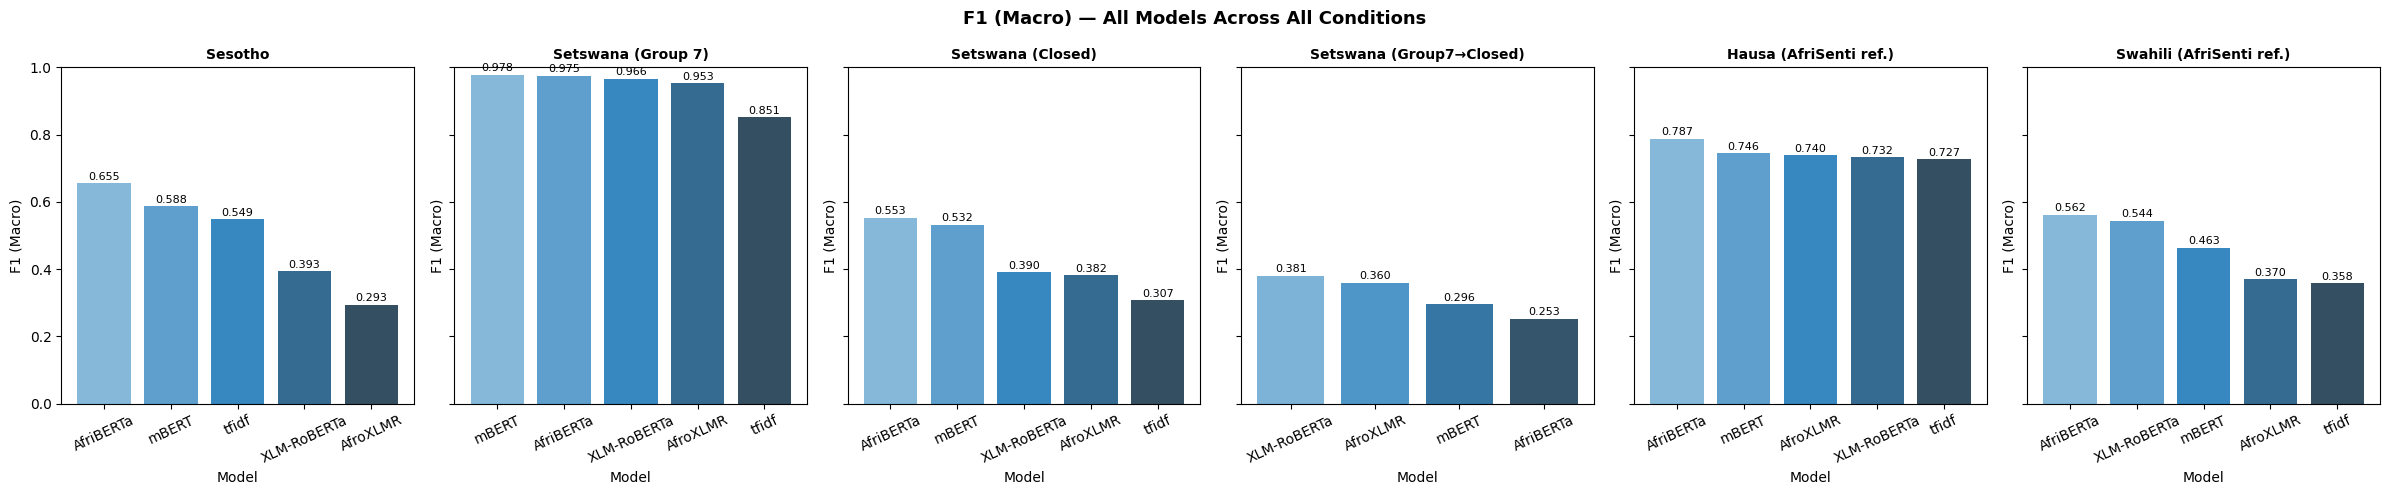

Saved: f1_comparison.png


In [ ]:
# F1 (Macro) bar charts
# Includes Sesotho, Setswana G7, Setswana Closed, and AfriSenti reference languages.

conditions = [
    ('SOT',             'Sesotho'),
    ('TSN',             'Setswana (Group 7)'),
    ('TSN_CLOSED',      'Setswana (Closed)'),
    ('TSN_CROSSCORPUS', 'Setswana (Group7→Closed)'),
    ('HAU',             'Hausa (AfriSenti ref.)'),
    ('SWA',             'Swahili (AfriSenti ref.)'),
]

available = [(c, l) for c, l in conditions if c in results_df['Condition'].values]
n = len(available)
fig, axes = plt.subplots(1, n, figsize=(4*n, 5), sharey=True)
if n == 1: axes = [axes]

for ax, (cond, label) in zip(axes, available):
    sub  = results_df[results_df['Condition'] == cond].copy()
    bars = ax.bar(sub['Model'], sub['F1 (Macro)'],
                  color=sns.color_palette('Blues_d', len(sub)))
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel('F1 (Macro)')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=25)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.suptitle('F1 (Macro) - All Models Across All Conditions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: f1_comparison.png')


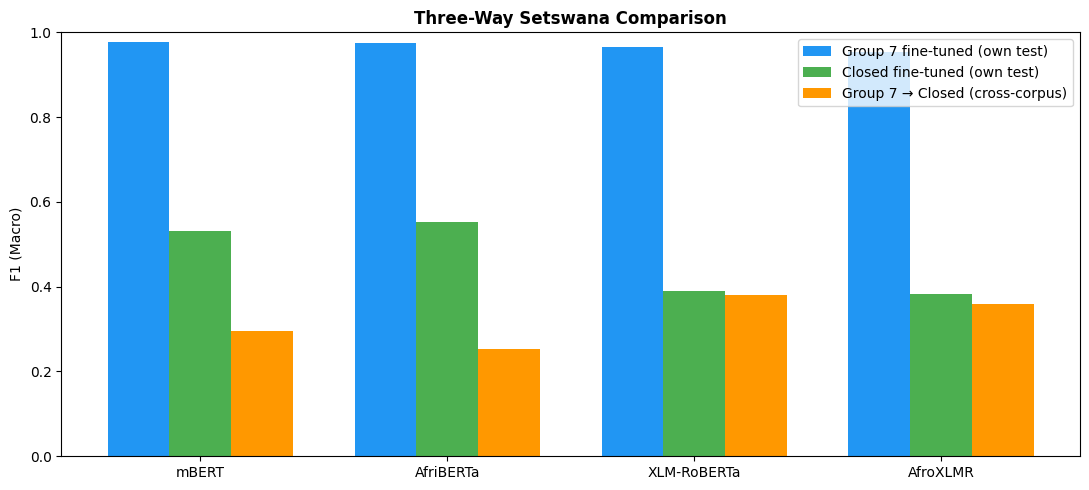

Saved: cross_corpus_comparison.png


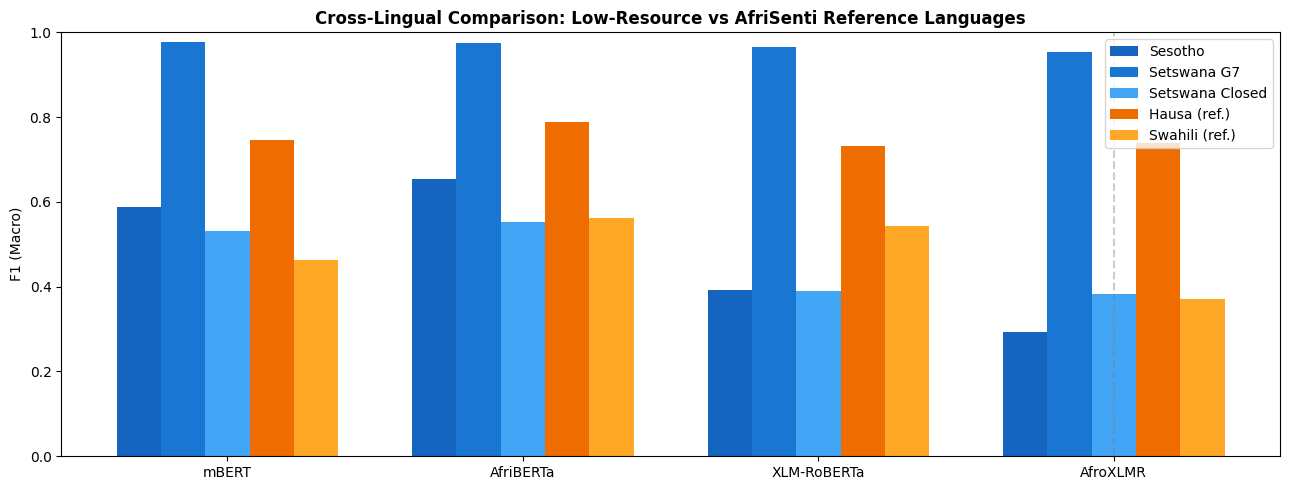

Saved: crosslingual_comparison.png


In [ ]:
# Two charts:
# 1. Three-way Setswana comparison (G7 fine-tuned vs Closed fine-tuned vs Cross-corpus)
# 2. Cross-lingual comparison: low-resource (SOT, TSN, Closed) vs reference (HAU, SWA)

model_keys = list(MODELS.keys())

# Chart 1: Three-way Setswana
if df_tsn_closed is not None:
    f1_g7     = [results.get(f'{k}_tsn', {}).get('f1_macro', 0) for k in model_keys]
    f1_closed = [results.get(f'{k}_tsn_closed', {}).get('f1_macro', 0) for k in model_keys]
    f1_cross  = [results.get(f'{k}_tsn_crosscorpus', {}).get('f1_macro', 0) for k in model_keys]

    x = range(len(model_keys))
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar([i - 0.25 for i in x], f1_g7,     width=0.25, label='Group 7 fine-tuned (own test)',  color='#2196F3')
    ax.bar([i        for i in x], f1_closed,  width=0.25, label='Closed fine-tuned (own test)',    color='#4CAF50')
    ax.bar([i + 0.25 for i in x], f1_cross,   width=0.25, label='Group 7 -> Closed (cross-corpus)', color='#FF9800')
    ax.set_xticks(list(x))
    ax.set_xticklabels(model_keys)
    ax.set_ylabel('F1 (Macro)')
    ax.set_ylim(0, 1.0)
    ax.set_title('Three-Way Setswana Comparison', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('/content/cross_corpus_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: cross_corpus_comparison.png')

# Chart 2: Low-resource vs AfriSenti reference languages
compare_conditions = [
    ('sot',        'Sesotho'),
    ('tsn',        'Setswana G7'),
    ('tsn_closed', 'Setswana Closed'),
    ('hau',        'Hausa (ref.)'),
    ('swa',        'Swahili (ref.)'),
]

fig, ax = plt.subplots(figsize=(13, 5))
x      = range(len(model_keys))
width  = 0.15
colors = ['#1565C0', '#1976D2', '#42A5F5', '#EF6C00', '#FFA726']

for j, (cond_key, cond_label) in enumerate(compare_conditions):
    f1_vals = [results.get(f'{k}_{cond_key}', {}).get('f1_macro', 0) for k in model_keys]
    offset  = (j - len(compare_conditions)/2) * width + width/2
    ax.bar([i + offset for i in x], f1_vals, width=width,
           label=cond_label, color=colors[j])

ax.set_xticks(list(x))
ax.set_xticklabels(model_keys)
ax.set_ylabel('F1 (Macro)')
ax.set_ylim(0, 1.0)
ax.set_title('Cross-Lingual Comparison: Low-Resource vs AfriSenti Reference Languages',
             fontweight='bold')
ax.legend(loc='upper right')
ax.axvline(x=len(model_keys) - 0.5 - 0.5, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/crosslingual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: crosslingual_comparison.png')


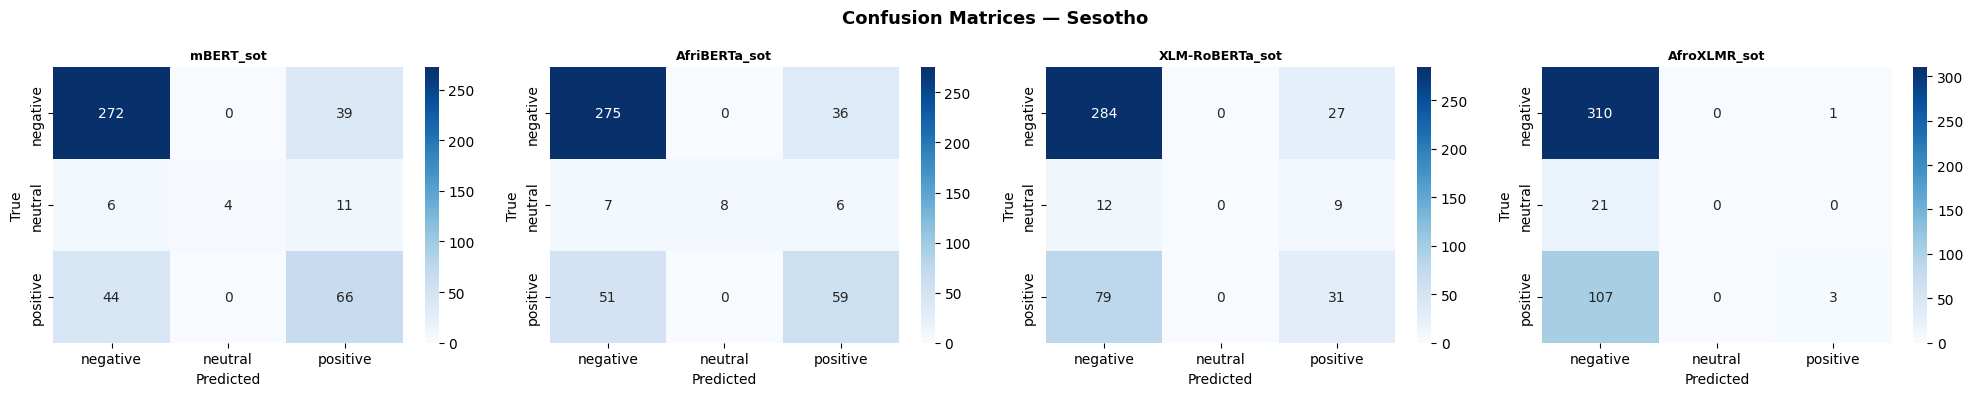

Saved: /content/confusion_matrices_Sesotho.png


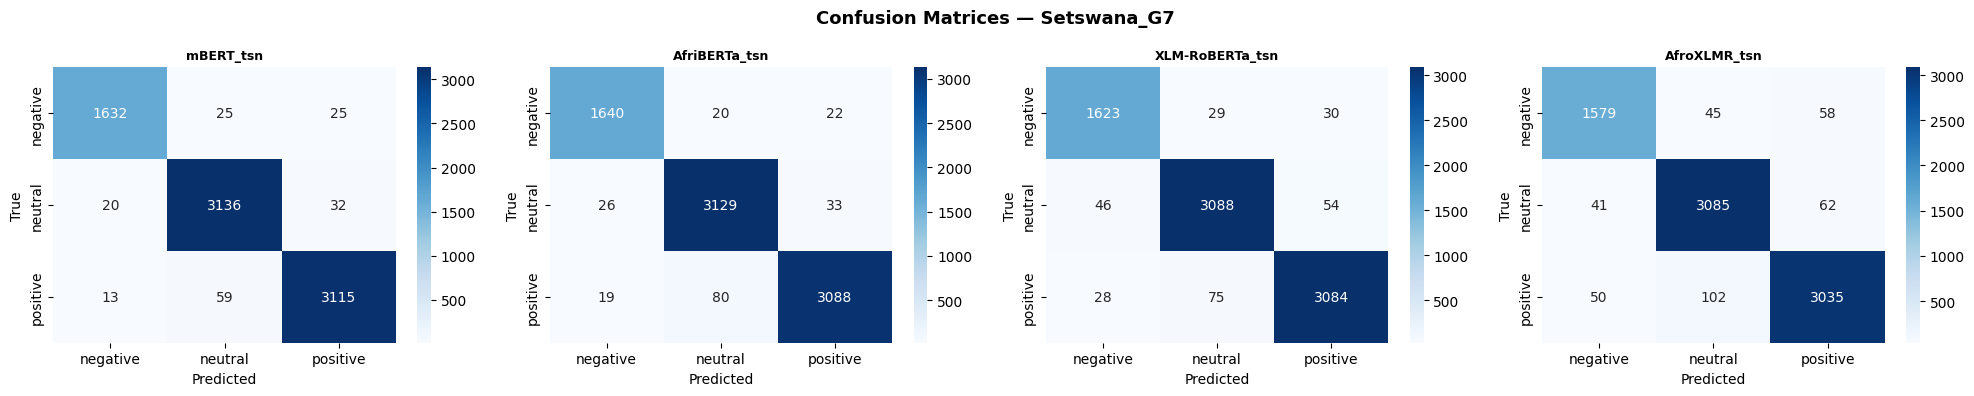

Saved: /content/confusion_matrices_Setswana_G7.png


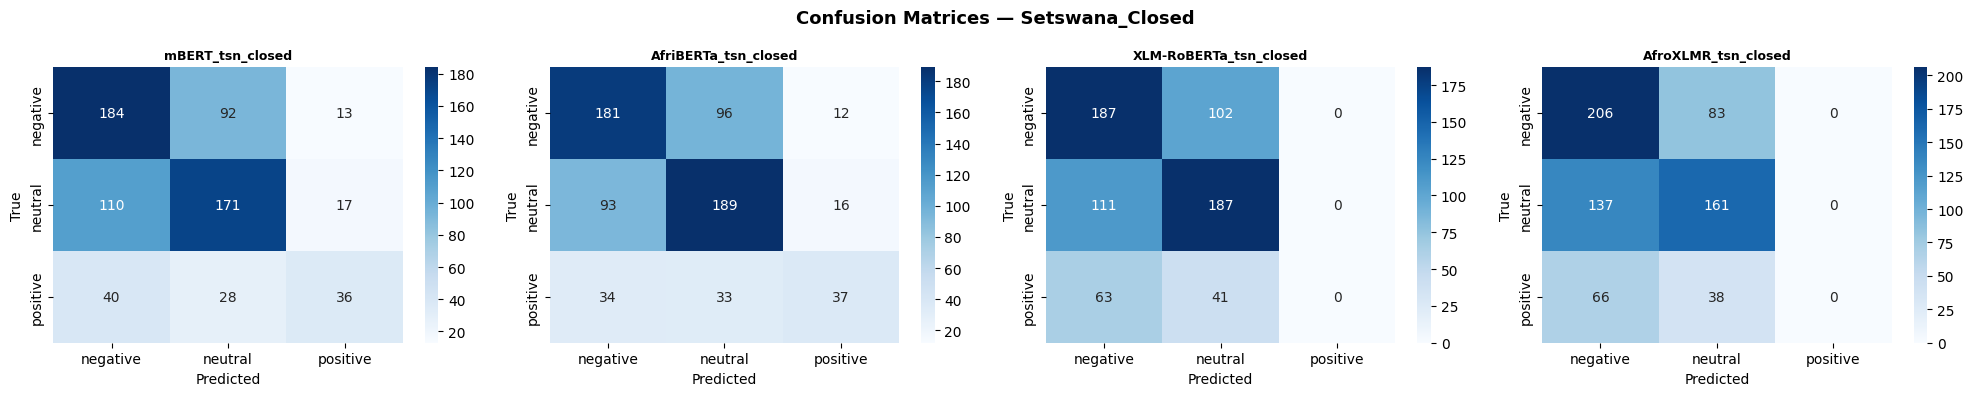

Saved: /content/confusion_matrices_Setswana_Closed.png


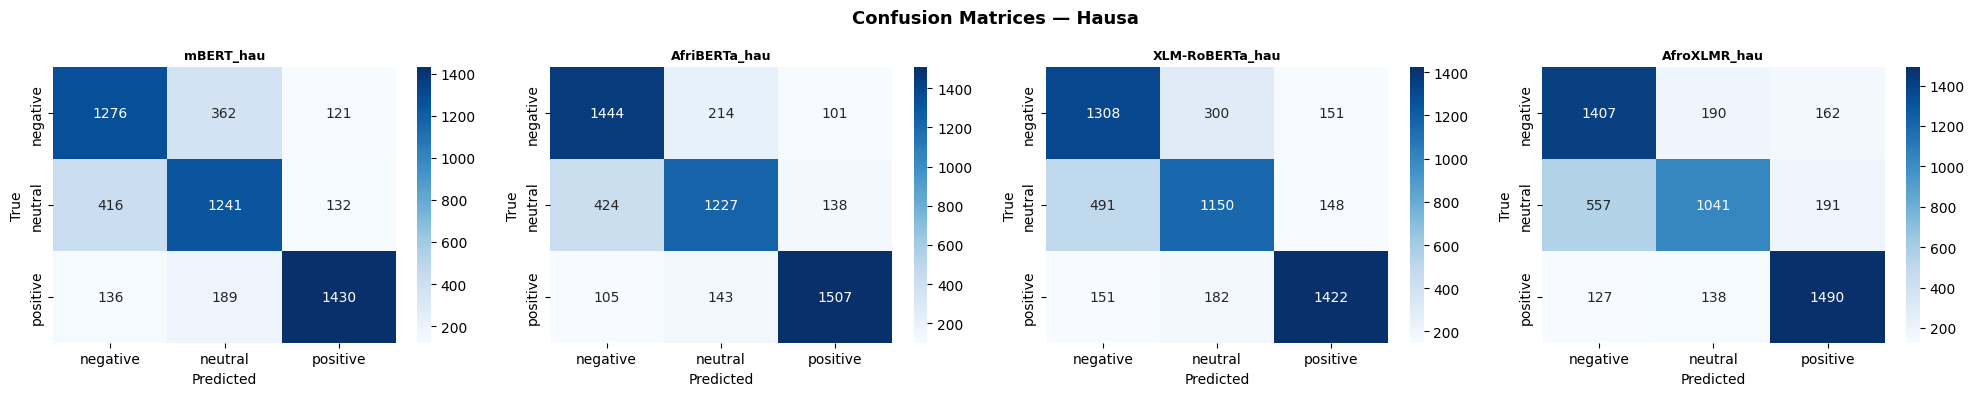

Saved: /content/confusion_matrices_Hausa.png


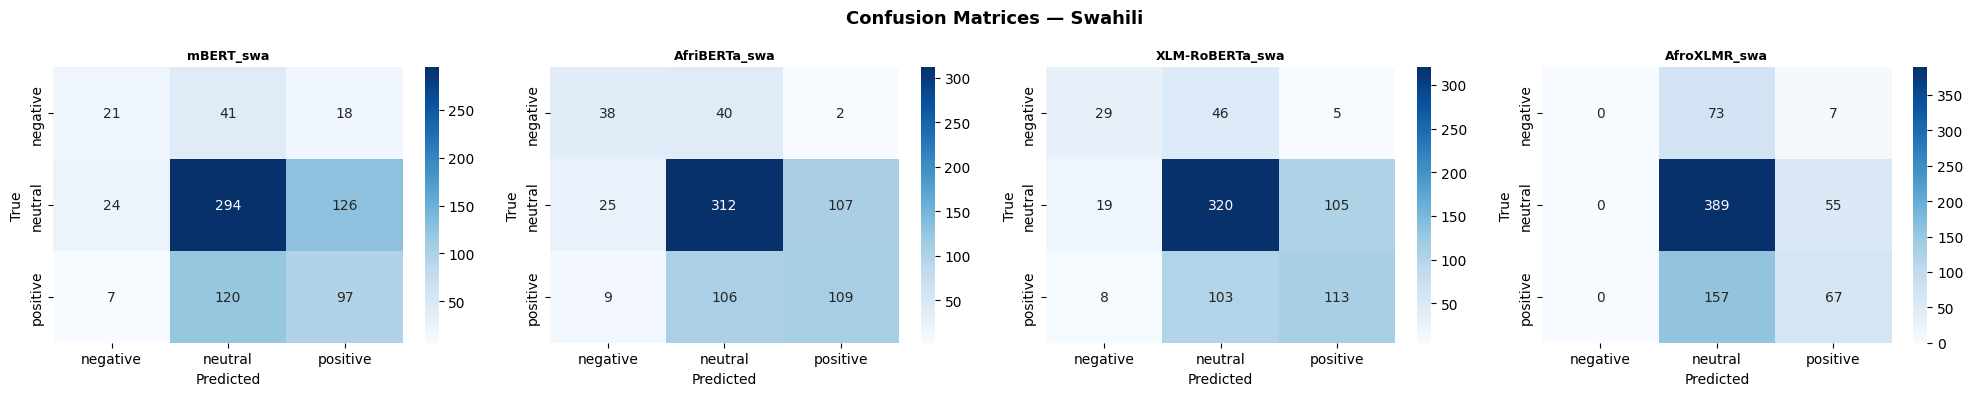

Saved: /content/confusion_matrices_Swahili.png


In [ ]:
# Confusion matrices: one PNG per language condition.

def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(LABEL2ID.keys()),
                yticklabels=list(LABEL2ID.keys()), ax=ax)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

languages = {
    'Sesotho':          ['mBERT_sot',        'AfriBERTa_sot',        'XLM-RoBERTa_sot',        'AfroXLMR_sot',        'tfidf_sot'],
    'Setswana_G7':      ['mBERT_tsn',        'AfriBERTa_tsn',        'XLM-RoBERTa_tsn',        'AfroXLMR_tsn',        'tfidf_tsn'],
    'Setswana_Closed':  ['mBERT_tsn_closed', 'AfriBERTa_tsn_closed', 'XLM-RoBERTa_tsn_closed', 'AfroXLMR_tsn_closed', 'tfidf_tsn_closed'],
    'Hausa':            ['mBERT_hau',        'AfriBERTa_hau',        'XLM-RoBERTa_hau',        'AfroXLMR_hau',        'tfidf_hau'],
    'Swahili':          ['mBERT_swa',        'AfriBERTa_swa',        'XLM-RoBERTa_swa',        'AfroXLMR_swa',        'tfidf_swa'],
}

for lang_name, keys in languages.items():
    available = [k for k in keys if k in all_preds]
    if not available:
        print(f'Skipping {lang_name} - no predictions found')
        continue

    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]

    for ax, k in zip(axes, available):
        plot_cm(all_true[k], all_preds[k], k, ax)

    plt.suptitle(f'Confusion Matrices - {lang_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'/content/confusion_matrices_{lang_name}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## Stage 8 - Explainability (SHAP and Attention Visualisation)

In [ ]:
# SHAP TextExplainer applied to the best-performing checkpoint (AfriBERTa on Sesotho).
# Token-level SHAP values reveal which linguistic features drive sentiment predictions,
# helping identify systematic misclassification patterns in Sesotho.

import shap

BEST_CKPT = os.path.join(CHECKPOINT_DIR, 'afriberta_large_Sesotho')

sentiment_pipeline = pipeline(
    'text-classification', model=BEST_CKPT, tokenizer=BEST_CKPT,
    return_all_scores=True, device=0 if DEVICE=='cuda' else -1
)
explainer    = shap.Explainer(sentiment_pipeline)
sample_texts = sot_test['text'].head(10).tolist()
shap_values  = explainer(sample_texts)

shap.plots.text(shap_values[0])
plt.savefig('/content/shap_text_plot.png', dpi=150, bbox_inches='tight')
print('Saved: shap_text_plot.png')

Loading weights:   0%|          | 0/169 [00:01<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/462 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 5/10 [00:22<00:09,  1.84s/it]

  0%|          | 0/380 [00:00<?, ?it/s]

...

PartitionExplainer explainer: 100%|██████████| 10/10 [00:59<00:00,  6.59s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [01:08,  6.88s/it]


Saved: shap_text_plot.png


<Figure size 640x480 with 0 Axes>

Loading weights:   0%|          | 0/169 [00:00<?, ?it/s]

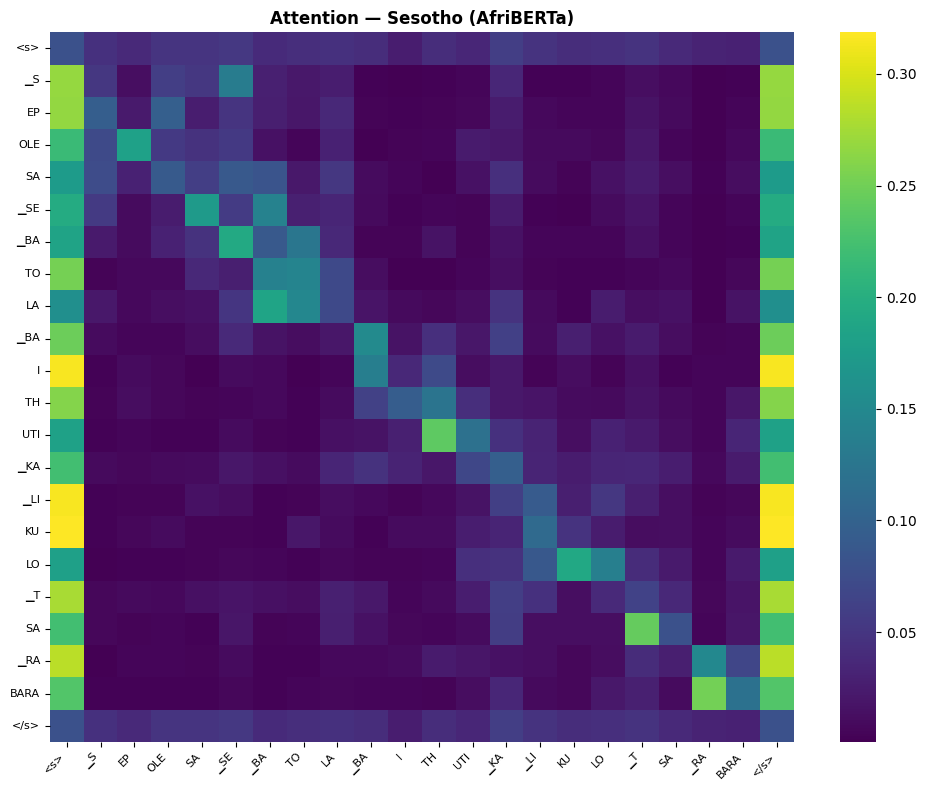

Saved: attention_heatmap.png


In [ ]:
# Attention heatmap from the final transformer layer, averaged across all heads.
# Visualising where the model attends when classifying Sesotho sentiment.

def get_attention(text, model_path):
    tok   = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_path, output_attentions=True
    ).to(DEVICE)
    model.eval()
    enc = tok(text, return_tensors='pt', truncation=True, max_length=128).to(DEVICE)
    with torch.no_grad():
        out = model(**enc)
    attn   = out.attentions[-1][0].mean(dim=0)
    tokens = tok.convert_ids_to_tokens(enc['input_ids'][0])
    return tokens, attn.cpu().numpy()

BEST_CKPT = os.path.join(CHECKPOINT_DIR, 'afriberta_large_Sesotho')
BEST_MODEL_KEY = 'AfriBERTa'

sample = sot_test['text'].iloc[0]
tokens, attn = get_attention(sample, BEST_CKPT)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap='viridis', ax=ax)
ax.set_title(f'Attention — Sesotho ({BEST_MODEL_KEY})', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_heatmap.png')

## Stage 9 - Results Summary and Export

In [ ]:
# Printing the final results table and saving to CSV for the report.

print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print(results_df.to_string(index=False))

results_df.to_csv('/content/results_summary.csv', index=False)
print('\nSaved: results_summary.csv')


FINAL RESULTS SUMMARY
      Model       Condition  Accuracy  Precision  Recall  F1 (Macro)  F1 (Weighted)
  AfriBERTa             HAU    0.7879     0.7899  0.7885      0.7874         0.7870
      mBERT             HAU    0.7443     0.7467  0.7446      0.7455         0.7451
   AfroXLMR             HAU    0.7426     0.7473  0.7436      0.7395         0.7390
XLM-RoBERTa             HAU    0.7317     0.7339  0.7322      0.7319         0.7315
      tfidf             HAU    0.7269     0.7350  0.7277      0.7267         0.7263
  AfriBERTa         HAU_AUG    0.7879     0.7899  0.7885      0.7874         0.7870
  AfriBERTa             SOT    0.7738     0.8033  0.6005      0.6550         0.7663
      mBERT             SOT    0.7738     0.8046  0.5550      0.5878         0.7653
      tfidf             SOT    0.7919     0.8477  0.5057      0.5492         0.7585
XLM-RoBERTa             SOT    0.7127     0.4067  0.3983      0.3928         0.6698
   AfroXLMR             SOT    0.7081     0.4859  0.3

In [ ]:
# Downloading all output files to local machine.
import shutil, os
from google.colab import files

output_files = [
    '/content/setswana_corpus_dist.png',
    '/content/setswana_corpus_comparison.png',
    '/content/cross_corpus_comparison.png',
    '/content/crosslingual_comparison.png',
    '/content/results_summary.csv',
    '/content/f1_comparison.png',
    '/content/confusion_matrices_Sesotho.png',
    '/content/confusion_matrices_Setswana_G7.png',
    '/content/confusion_matrices_Setswana_Closed.png',
    '/content/confusion_matrices_Hausa.png',
    '/content/confusion_matrices_Swahili.png',
    '/content/shap_text_plot.png',
    '/content/attention_heatmap.png',
]

for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'Downloaded: {f}')
    else:
        print(f'Not yet generated: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/setswana_corpus_dist.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: /content/shap_text_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/attention_heatmap.png
